## Common setup

In [1]:
import dotenv
%load_ext dotenv
%dotenv

import os
import platform
import json
import random
import time

import jax
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from absl import app, flags
from ml_collections import config_flags

from agents import agents
from envs.env_utils import make_env_and_datasets
from utils.datasets import Dataset, ReplayBuffer
from utils.evaluation import evaluate, flatten, supply_rng
from utils.flax_utils import restore_agent

import jax
import numpy as np
import matplotlib.pyplot as plt

def supply_rng(f, rng=jax.random.PRNGKey(0)):
    """Helper function to split the random number generator key before each call to the function."""

    def wrapped(*args, **kwargs):
        nonlocal rng
        rng, key = jax.random.split(rng)
        return f(*args, seed=key, **kwargs)

    return wrapped

/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


In [3]:
from utils.networks import LatentLyapunovFunction

def load_lyapunov_network(model_path, model_step, lyapunov_fn, state_dim, action_dim):
    """Load the saved Lyapunov network parameters."""
    import pickle
    
    # Load parameters
    params_path = os.path.join(model_path, f'lyapunov_params_step_{model_step}.npz')
    tree_path = os.path.join(model_path, f'lyapunov_tree_step_{model_step}.pkl')
    
    if not os.path.exists(params_path):
        raise FileNotFoundError(f"Parameters file not found: {params_path}")
    if not os.path.exists(tree_path):
        raise FileNotFoundError(f"Tree structure file not found: {tree_path}")
    
    # Load tree definition
    with open(tree_path, 'rb') as f:
        tree_def = pickle.load(f)
    
    # Load flattened parameters
    params_data = np.load(params_path)
    flat_params = [params_data[f'arr_{i}'] for i in range(len(params_data.files))]
    
    # Reconstruct parameter tree
    params = jax.tree_util.tree_unflatten(tree_def, flat_params)
    
    print(f"Loaded Lyapunov network from {model_path} at step {model_step}")
    return params

def create_energy_function(lyapunov_fn, lyapunov_params):
    """
    Create an energy function from the Lyapunov function.
    The energy function should return lower values for safer actions.
    """
    def energy_fn(observations, actions):
        try:
            # Use the Lyapunov function to compute energy
            # Lower Lyapunov values (more negative) should correspond to lower energy (safer actions)
            lyapunov_values = lyapunov_fn.apply(lyapunov_params, observations, actions)
            # Return negative Lyapunov values as energy (lower energy = safer)
            return lyapunov_values
        except Exception as e:
            print(f"Error in energy function: {e}")
            # Return zero energy if there's an error
            return jnp.zeros(observations.shape[0])
    
    # JIT compile the energy function for better performance
    return jax.jit(energy_fn)

# Get state and action dimensions from environment
state_dim = example_batch['observations'].shape[-1]
action_dim = example_batch['actions'].shape[-1]

# Create Lyapunov network
hidden_dims = [512,512,512]
latent_dim=16
layer_norm=False
lyapunov_fn = LatentLyapunovFunction(
    hidden_dim=hidden_dims,
    state_dim=state_dim,
    action_dim=action_dim,
    latent_dim=latent_dim,
    layer_norm=layer_norm
)

lyp_antmaze_task1="/mnt/nas/jaehyeok/fql/exp/lyapunov/LyapunovTraining/lyapunov_antmaze-large-navigate-singletask-task1-v0_sd000_20250916_202904"
lyp_antmaze_task2="/mnt/nas/jaehyeok/fql/exp/lyapunov/LyapunovTraining/lyapunov_antmaze-large-navigate-singletask-task2-v0_sd000_20250919_172659"
lyp_antmaze_task3="/mnt/nas/jaehyeok/fql/exp/lyapunov/LyapunovTraining/lyapunov_antmaze-large-navigate-singletask-task3-v0_sd000_20250919_172726"

lyapunov_model_path=lyp_antmaze_task2


# Load trained parameters
lyapunov_params = load_lyapunov_network(
    lyapunov_model_path, 
    1000000, 
    lyapunov_fn, 
    state_dim, 
    action_dim
)

# Create energy function
energy_fn = create_energy_function(lyapunov_fn, lyapunov_params)
print(energy_fn is None)

Loaded Lyapunov network from /mnt/nas/jaehyeok/fql/exp/lyapunov/LyapunovTraining/lyapunov_antmaze-large-navigate-singletask-task2-v0_sd000_20250919_172659 at step 1000000
False


In [4]:
def get_success_failure_idx(trajs):
    success_idx = []
    failure_idx = []
    for i in range(len(trajs)):
        if trajs[i]['reward'][-1] != -1:
            success_idx.append(i)
        else:
            failure_idx.append(i)

    return success_idx, failure_idx

def compute_q_values(agent, states, actions, batch_size=256):
    q_values = []
    num_data = states.shape[0]

    for batch_start in tqdm(range(0, num_data, batch_size)):
        batch_end = min(batch_start + batch_size, num_data)
        batch_states = states[batch_start:batch_end]
        batch_actions = actions[batch_start:batch_end]

        # Reshape for broadcasting, if needed
        batch_observations = batch_states.reshape(batch_states.shape[0], -1)
        batch_target_actions = batch_actions.reshape(batch_actions.shape[0], -1)

        qs = agent.network.select('critic')(batch_observations, batch_target_actions).mean(axis=0)
        q_values.extend(qs if np.ndim(qs) == 1 else qs.tolist())

    q_values = np.array(q_values)
    print(q_values.shape)

    return q_values

def compute_ref_target_q_values(agent, states, actions, key, num_states=100, num_samples=50):
    quantiles = []
    ref_actions_list = []
    ref_qs_list = []
    target_actions_list = []
    target_q_list = []

    evaluation_idx = np.random.randint(0, states.shape[0], size=num_states)
    for i in tqdm(evaluation_idx):
        target_action = actions[i,...]
        observation = states[i,...]

        n_observations = observation.reshape(1,-1).repeat(num_samples, axis=0)
        ref_actions = agent.sample_actions(n_observations, seed=key)
        ref_qs = agent.network.select('critic')(n_observations, ref_actions).mean(axis=0)

        target_q = agent.network.select('critic')(observation.reshape(1,-1), target_action.reshape(1,-1)).mean(axis=0)
        quantile = (ref_qs < target_q).mean()

        ref_actions_list.append(ref_actions)
        ref_qs_list.append(ref_qs)
        target_actions_list.append(target_action)
        target_q_list.append(target_q)
        quantiles.append(quantile)
    
    quantiles = np.array(quantiles)
    return ref_actions_list, ref_qs_list, target_actions_list, target_q_list, quantiles

## FBRAC Analysis

In [5]:
# Configuration (following run_fbrac_pipeline.sh pattern)
task_idx = 1
fbrac_env_name = f"antmaze-large-navigate-singletask-task{task_idx}-v0"
fbrac_env_name = f"humanoidmaze-medium-navigate-singletask-task{task_idx}-v0"
seed = 0
buffer_size = 2000000
eval_episodes = 10

# Training hyperparameters (from run_fbrac_pipeline.sh)
alpha = 30
flow_steps = 10
q_agg = "mean"
discount = 0.995
offline_steps = 1000000

# ============================================================================
# CRITICAL FOR DETERMINISM: Set PYTHONHASHSEED (matching guidance_evaluation.py)
# ============================================================================
os.environ['PYTHONHASHSEED'] = str(seed)

# Build experiment name and path (following run_fbrac_pipeline.sh pattern)
exp_name = f"{fbrac_env_name}_alpha{alpha}-flow{flow_steps}-qagg{q_agg}-discount{discount}_sd{seed:03d}"
base_dir = "exp"
run_group = fbrac_env_name
agent_path = f"{base_dir}/fbrac/{run_group}/{exp_name}"
restore_epoch = offline_steps

# Make environment and datasets (BEFORE seeding - matching guidance_evaluation.py order)
fbrac_env, fbrac_eval_env, fbrac_train_dataset, fbrac_val_dataset = make_env_and_datasets(fbrac_env_name, frame_stack=None)
fbrac_train_dataset = Dataset.create(**fbrac_train_dataset)
fbrac_train_dataset = ReplayBuffer.create_from_initial_dataset(
    dict(fbrac_train_dataset), size=max(buffer_size, fbrac_train_dataset.size + 1)
)

# ============================================================================
# Initialize random seeds AFTER environment creation (matching guidance_evaluation.py)
# ============================================================================
random.seed(seed)
np.random.seed(seed)
master_key = jax.random.PRNGKey(int(seed))

# Seed environment action space for determinism
if hasattr(fbrac_eval_env, 'action_space'):
    fbrac_eval_env.action_space.seed(seed)

example_batch = fbrac_train_dataset.sample(1)

# Load agent config (following guidance_evaluation.py pattern)
import importlib.util
agent_config_path = "agents/fbrac.py"
spec = importlib.util.spec_from_file_location("agent_config", agent_config_path)
agent_config_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(agent_config_module)
fbrac_config = agent_config_module.get_config()

# Set hyperparameters in config (following run_fbrac_pipeline.sh pattern)
fbrac_config.alpha = alpha
fbrac_config.flow_steps = flow_steps
fbrac_config.q_agg = q_agg
fbrac_config.discount = discount

# Create agent (following guidance_evaluation.py pattern)
agent_class = agents[fbrac_config['agent_name']]
fbrac_agent = agent_class.create(
    seed,
    example_batch['observations'],
    example_batch['actions'],
    fbrac_config,
)

# Restore agent (following guidance_evaluation.py pattern)
if agent_path and restore_epoch:
    fbrac_agent = restore_agent(fbrac_agent, agent_path, restore_epoch)
    print(f"Agent restored from {agent_path} at epoch {restore_epoch}")

print("Models loaded successfully!")
print(f"✓ Master key initialized: {master_key}")
print(f"✓ PYTHONHASHSEED set to: {seed}")
print(f"✓ All seeds set for deterministic evaluation")

Restored from exp/fbrac/humanoidmaze-medium-navigate-singletask-task1-v0/humanoidmaze-medium-navigate-singletask-task1-v0_alpha30-flow10-qaggmean-discount0.995_sd000/params_1000000.pkl
Agent restored from exp/fbrac/humanoidmaze-medium-navigate-singletask-task1-v0/humanoidmaze-medium-navigate-singletask-task1-v0_alpha30-flow10-qaggmean-discount0.995_sd000 at epoch 1000000
Models loaded successfully!
✓ Master key initialized: [0 0]
✓ PYTHONHASHSEED set to: 0
✓ All seeds set for deterministic evaluation


In [9]:
def get_success_failure_idx(trajs):
    success_idx = []
    failure_idx = []
    for i in range(len(trajs)):
        if trajs[i]['reward'][-1] != -1:
            success_idx.append(i)
        else:
            failure_idx.append(i)

    return success_idx, failure_idx

def compute_q_values(agent, states, actions, batch_size=256):
    q_values = []
    num_data = states.shape[0]

    for batch_start in tqdm(range(0, num_data, batch_size)):
        batch_end = min(batch_start + batch_size, num_data)
        batch_states = states[batch_start:batch_end]
        batch_actions = actions[batch_start:batch_end]

        # Reshape for broadcasting, if needed
        batch_observations = batch_states.reshape(batch_states.shape[0], -1)
        batch_target_actions = batch_actions.reshape(batch_actions.shape[0], -1)

        qs = agent.network.select('critic')(batch_observations, batch_target_actions).mean(axis=0)
        q_values.extend(qs if np.ndim(qs) == 1 else qs.tolist())

    q_values = np.array(q_values)
    print(q_values.shape)

    return q_values

def compute_ref_target_q_values(agent, states, actions, key, num_states=100, num_samples=50):
    quantiles = []
    ref_actions_list = []
    ref_qs_list = []
    target_actions_list = []
    target_q_list = []

    evaluation_idx = np.random.randint(0, states.shape[0], size=num_states)
    for i in tqdm(evaluation_idx):
        target_action = actions[i,...]
        observation = states[i,...]

        n_observations = observation.reshape(1,-1).repeat(num_samples, axis=0)
        ref_actions = agent.sample_actions(n_observations, seed=key)

        print(n_observations.shape)
        print(ref_actions.shape)
        ref_qs = agent.network.select('critic')(n_observations, ref_actions).mean(axis=0)

        target_q = agent.network.select('critic')(observation.reshape(1,-1), target_action.reshape(1,-1)).mean(axis=0)
        quantile = (ref_qs < target_q).mean()

        ref_actions_list.append(ref_actions)
        ref_qs_list.append(ref_qs)
        target_actions_list.append(target_action)
        target_q_list.append(target_q)
        quantiles.append(quantile)
    
    quantiles = np.array(quantiles)
    return ref_actions_list, ref_qs_list, target_actions_list, target_q_list, quantiles

In [ ]:
import jax.numpy as jnp
from tqdm import trange


def sample_action_with_guidance(
        agent,
        observations,
        energy_fn,
        seed=None,
        guidance_coeff=1.0,
        temperature=1.0,
        partial_guidance=-1,
    ):
        """
        Sample actions from the policy with energy-based guidance.
        
        Args:
            observations: Current observations
            energy_fn: Energy function that takes (observations, actions) and returns energy values
            seed: Random seed for sampling
            guidance_coeff: Guidance strength coefficient
            temperature: Sampling temperature
            partial_guidance: If -1, apply guidance for entire sampling process.
                            If > 0 and < flow_steps, apply guidance only to last {partial_guidance} steps.
            
        Returns:
            actions: Sampled actions with guidance applied
            energy_vals: List of energy values computed during sampling
            gradient_vals: List of gradient values computed during sampling
            cosine_sim_vals: List of cosine similarity values between Q-gradient and safety gradient
        """
        
        # In place condition for experiment purpose
        rescale_strategy="normalize" # to be move to guidance_evaluation main function
        pred_clean=True
        guidance_scheduling="fixed"
        last_step_guidance=True

        def get_guidance_strength(i, exp_k=5):
            """
            Treat the guidance_coeff as max strength
            """
            min_guidance = 1e-3

            if guidance_scheduling == "fixed":
                return guidance_coeff
            elif guidance_scheduling == "neg_linear": # start from guidance_coeff and decrease linearly
                return guidance_coeff - (guidance_coeff - min_guidance) * (i+1) / flow_steps
            elif guidance_scheduling == "linear":
                return min_guidance + (guidance_coeff - min_guidance) * (i+1) / flow_steps
            elif guidance_scheduling == "exp":
                factor = (jnp.exp((i+1)*exp_k/flow_steps) - 1)/(jnp.exp(exp_k) - 1)
                return min_guidance + (guidance_coeff - min_guidance) * factor
            else:
                raise ValueError(f"Invalid guidance_scheduling: {guidance_scheduling}")
        
        # Original fixed guidance coefficient method
        vels_list = []
        gradient_vals = []
        clean_preds = []
        actions_list = []
        action_seed, noise_seed = jax.random.split(seed)
        noises = jax.random.normal(
            action_seed,
            (
                *observations.shape[: -len(agent.config['ob_dims'])],
                agent.config['action_dim'],
            ),
        )
        actions = noises
        
        # Initialize EMA for guidance gradient smoothing
        ema_guidance = jnp.zeros_like(actions)
        
        # Determine when to apply guidance based on partial_guidance and last_step_guidance parameters
        flow_steps = agent.config['flow_steps']
        if partial_guidance == -1:
            # Apply guidance for entire sampling process
            guidance_start_step = 0
            guidance_end_step = flow_steps
        elif 0 < partial_guidance < flow_steps:
            # Apply guidance to partial steps based on last_step_guidance flag
            if last_step_guidance:
                # Apply guidance only to last {partial_guidance} steps
                guidance_start_step = flow_steps - partial_guidance
                guidance_end_step = flow_steps
            else:
                # Apply guidance only to first {partial_guidance} steps
                guidance_start_step = 0
                guidance_end_step = partial_guidance
        else:
            # Invalid partial_guidance value, default to no guidance
            guidance_start_step = flow_steps
            guidance_end_step = flow_steps
            print(f"Warning: Invalid partial_guidance value {partial_guidance}. Using no guidance.")
        
        # Pre-compile the gradient function once for better performance (only if we'll use guidance)
        energy_grad_fn = None
        if guidance_start_step < flow_steps:
            try:
                energy_grad_fn = agent._get_energy_grad_fn(energy_fn)
            except Exception as e:
                print(f"Error pre-compiling gradient function: {e}")
                energy_grad_fn = None
        
        # Apply flow steps with conditional guidance
        for i in range(flow_steps):
            t = jnp.full((*observations.shape[:-1], 1), i / flow_steps)
            
            # Get the flow velocity from the actor
            vels = agent.network.select('actor_bc_flow')(observations, actions, t)

            guidance_weight = get_guidance_strength(i)

            # Only compute energy and guidance if guidance_coeff is not zero and energy > -5
            # Use JAX conditional operations for JIT compatibility
            def apply_guidance():
                if energy_grad_fn is not None:
                    # safety_grad = energy_grad_fn(observations, target_actions)

                    # Compute Q value at target_actions, but gradient w.r.t. current actions
                    def q_fn_at_target(a_t):
                        if pred_clean:
                            # Compute target_actions from a_t
                            a_1 = a_t + (1 - t) * vels
                            a_1 = jnp.clip(a_1, -1, 1)
                        else:
                            a_1 = a_t
                        qs = agent.network.select('critic')(observations, a_1)
                        return jnp.mean(qs)
                    
                    q_grad = jax.grad(q_fn_at_target)(actions)  # Gradient w.r.t. a_t

                    # guidance_grad = q_grad/jnp.linalg.norm(q_grad) - safety_grad/jnp.linalg.norm(safety_grad) # to match a scale
                    guidance_grad_raw = q_grad

                    if rescale_strategy == "normalize":
                        # normalize
                        guidance_grad_raw = guidance_grad_raw / (1e-8 + jnp.linalg.norm(guidance_grad_raw))
                    
                    return guidance_grad_raw, 0.0
                else:
                    return jnp.zeros_like(vels), 0.0
            
            def no_guidance():
                return jnp.zeros_like(vels), 0.0
            
            # Check if we should apply guidance
            should_apply = (guidance_coeff != 0.0 and 
                          i >= guidance_start_step and 
                          i < guidance_end_step and
                          energy_grad_fn is not None)
            
            # Use JAX conditional to choose guidance or no guidance
            guidance_grad_raw, _ = jax.lax.cond(
                should_apply,
                apply_guidance,
                no_guidance
            )
            
            # Exponential Moving Average smoothing
            beta_t = 0.3 + (0.9 - 0.3) * (i / flow_steps)
            ema_guidance = beta_t * ema_guidance + (1 - beta_t) * guidance_grad_raw
            
            # Blend raw gradient with EMA
            rho = 0.5  # 0.3-0.7 works well
            guidance_grad = (1 - rho) * guidance_grad_raw + rho * ema_guidance
            
            # Check for NaN/Inf in guidance gradient
            guidance_grad = jnp.where(
                jnp.isnan(guidance_grad) | jnp.isinf(guidance_grad),
                0.0,
                guidance_grad
            )
            guidance_grad = jnp.clip(guidance_weight*guidance_grad, -1, 1)

            gradient_vals.append(guidance_grad)
            vels_list.append(vels)
            a_1 = actions + (1 - t) * vels
            a_1 = jnp.clip(a_1, -1, 1)
            clean_preds.append(a_1)
            actions_list.append(actions)
            guided_vels = vels + guidance_grad
            
            # Update actions
            actions = actions + guided_vels / flow_steps
        
        actions = jnp.clip(actions, -1, 1)
        return actions, vels_list, gradient_vals, clean_preds, actions_list

In [185]:
def eval_guidance(
    agent,
    env,
    energy_fn,
    config=None,
    num_eval_episodes=50,
    eval_temperature=0,
    guidance_coeff=1.0,
    partial_guidance=-1,
    seed=0,
    key=None,
):
    """Evaluate the agent in the environment using guided sampling.

    Args:
        agent: Agent with sample_action_with_guidance method.
        env: Environment.
        energy_fn: Energy function for guidance.
        config: Configuration dictionary.
        num_eval_episodes: Number of episodes to evaluate the agent.
        eval_temperature: Action sampling temperature.
        guidance_coeff: Guidance strength coefficient.
        partial_guidance: If -1, apply guidance for entire sampling process.
                         If > 0 and < flow_steps, apply guidance only to last {partial_guidance} steps.

    Returns:
        A tuple containing the statistics, trajectories, energy values, gradient values, and lambda values.
    """
    from collections import defaultdict
    
    # Create guided actor function
    def guided_actor_fn(observations, seed=None, temperature=eval_temperature):
        # Use regular fixed coefficient guidance method
        return sample_action_with_guidance(
            agent=agent,
            observations=observations,
            energy_fn=energy_fn,
            seed=seed,
            guidance_coeff=guidance_coeff,
            temperature=temperature,
            partial_guidance=partial_guidance
        )

    print(f"JIT-compiling guided actor function for coeff={guidance_coeff}...")
    if key is None:
        key = jax.random.PRNGKey(int(seed))
    guided_actor_fn = jax.jit(guided_actor_fn)
    trajs = []
    stats = defaultdict(list)
    energy_vals_by_episode = []
    gradient_vals_by_episode = []
    lambda_vals_by_episode = []
    cosine_sim_vals_by_episode = []

    for i in trange(num_eval_episodes, desc=f"Evaluating coeff={guidance_coeff}"):
        key, ep_key = jax.random.split(key)
        traj = defaultdict(list)
        energy_vals_list = []
        gradient_vals_list = []
        lambda_vals_list = []
        cosine_sim_vals_list = []
        observation, info = env.reset(seed=i)
        done = False
        step = 0
        while not done:
            ep_key, action_key = jax.random.split(ep_key)
            result = guided_actor_fn(observations=observation, temperature=eval_temperature, seed=action_key)
            # Handle different return formats based on guidance method
            if isinstance(result, tuple) and len(result) == 5:
                # Covariance method returns (action, energy_vals, gradient_vals, lambda_vals, cosine_sim_vals)
                action, energy_vals, gradient_vals, lambda_vals, cosine_sim_vals = result
                energy_vals_list.append(energy_vals)
                gradient_vals_list.append(gradient_vals)
                lambda_vals_list.append(lambda_vals)
                cosine_sim_vals_list.append(cosine_sim_vals)
            elif isinstance(result, tuple) and len(result) == 4:
                # Regular method returns (action, energy_vals, gradient_vals, cosine_sim_vals)
                action, energy_vals, gradient_vals, cosine_sim_vals = result
                energy_vals_list.append(energy_vals)
                gradient_vals_list.append(gradient_vals)
                cosine_sim_vals_list.append(cosine_sim_vals)
                # Create dummy lambda values if not provided
                lambda_vals_list.append([0.0])
            elif isinstance(result, tuple) and len(result) == 3:
                # Legacy format: (action, energy_vals, gradient_vals)
                action, energy_vals, gradient_vals = result
                energy_vals_list.append(energy_vals)
                gradient_vals_list.append(gradient_vals)
                # Create dummy lambda and cosine similarity values if not provided
                lambda_vals_list.append([0.0])
                cosine_sim_vals_list.append([0.0])
            elif isinstance(result, tuple) and len(result) == 2:
                action, energy_vals = result
                energy_vals_list.append(energy_vals)
                # Create dummy gradient, lambda, and cosine similarity values if not provided
                gradient_vals_list.append([jnp.zeros_like(observation)])
                lambda_vals_list.append([0.0])
                cosine_sim_vals_list.append([0.0])
            else:
                action = result
                # Create dummy energy, gradient, lambda, and cosine similarity values if not provided
                energy_vals_list.append(jnp.zeros(1))
                gradient_vals_list.append([jnp.zeros_like(observation)])
                lambda_vals_list.append([0.0])
                cosine_sim_vals_list.append([0.0])
            
            action = np.array(action)
            action = np.clip(action, -1, 1)

            next_observation, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            step += 1

            transition = dict(
                observation=observation,
                next_observation=next_observation,
                action=action,
                reward=reward,
                done=done,
                info=info,
            )
            from utils.evaluation import add_to
            add_to(traj, transition)
            observation = next_observation
        energy_vals_by_episode.append(energy_vals_list)
        gradient_vals_by_episode.append(gradient_vals_list)
        lambda_vals_by_episode.append(lambda_vals_list)
        cosine_sim_vals_by_episode.append(cosine_sim_vals_list)
        add_to(stats, flatten(info))
        trajs.append(traj)

    # Convert gradient values to regular Python lists for consistency
    def convert_nested_episodes(episodes):
        if episodes and len(episodes) > 0:
            converted_episodes = []
            for episode_vals in episodes:
                episode_list = []
                for val in episode_vals:
                    if hasattr(val, 'tolist'):
                        episode_list.append(val.tolist())
                    elif isinstance(val, (list, tuple)):
                        episode_list.append(list(val))
                    else:
                        episode_list.append(float(val))
                converted_episodes.append(episode_list)
            return converted_episodes
        else:
            return []

    gradient_vals_by_episode = convert_nested_episodes(gradient_vals_by_episode)
    energy_vals_by_episode = convert_nested_episodes(energy_vals_by_episode)
    cosine_sim_vals_by_episode = convert_nested_episodes(cosine_sim_vals_by_episode)
    lambda_vals_by_episode = convert_nested_episodes(lambda_vals_by_episode)

    for k, v in stats.items():
        stats[k] = np.mean(v)

    return stats, trajs, energy_vals_by_episode, gradient_vals_by_episode, lambda_vals_by_episode, cosine_sim_vals_by_episode

In [10]:
def evaluate_with_rejection_sampling(
    agent,
    env,
    energy_fn,
    config=None,
    num_eval_episodes=50,
    eval_temperature=0,
    select_quantile=1.0,
    seed=0,
    key=None,
):
    """Evaluate the agent in the environment using rejection sampling.

    Args:
        agent: Agent with rejection_sample_actions method.
        env: Environment.
        energy_fn: Energy function (not used in rejection sampling, kept for compatibility).
        config: Configuration dictionary.
        num_eval_episodes: Number of episodes to evaluate the agent.
        eval_temperature: Action sampling temperature.
        select_quantile: Quantile to select the action from the rejection sampling.
        seed: Random seed.
        key: JAX random key.

    Returns:
        A tuple containing the statistics and trajectories.
    """
    from collections import defaultdict
    
    # Create rejection sampling actor function
    def rejection_actor_fn(observations, seed=None, temperature=eval_temperature):
        return agent.rejection_sample_actions(
            observations=observations,
            seed=seed,
            temperature=temperature,
            select_quantile=select_quantile
        )
    
    # JIT-compile the rejection sampling actor function for better performance
    print(f"JIT-compiling rejection sampling actor function with quantile={select_quantile}...")
    if key is None:
        key = jax.random.PRNGKey(int(seed))
    rejection_actor_fn = jax.jit(rejection_actor_fn)
    trajs = []
    stats = defaultdict(list)

    for i in trange(num_eval_episodes, desc=f"Evaluating with rejection sampling (quantile={select_quantile})"):
        key, ep_key = jax.random.split(key)
        traj = defaultdict(list)
        observation, info = env.reset(seed=i)
        done = False
        step = 0
        while not done:
            ep_key, action_key = jax.random.split(ep_key)
            action = rejection_actor_fn(observations=observation, temperature=eval_temperature, seed=ep_key)
            
            action = np.array(action)
            action = np.clip(action, -1, 1)

            next_observation, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            step += 1

            transition = dict(
                observation=observation,
                next_observation=next_observation,
                action=action,
                reward=reward,
                done=done,
                info=info,
            )
            from utils.evaluation import add_to
            add_to(traj, transition)
            observation = next_observation
        
        add_to(stats, flatten(info))
        trajs.append(traj)

    for k, v in stats.items():
        stats[k] = np.mean(v)

    return stats, trajs

### Reference Model

In [10]:
random.seed(seed)
np.random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
master_key = jax.random.PRNGKey(int(seed))

stats, trajs, energy_vals_by_episode, gradient_vals_by_episode, lambda_vals_by_episode, cosine_sim_vals_by_episode = eval_guidance(
    agent=fbrac_agent,
    config=fbrac_config,
    env=fbrac_eval_env,
    energy_fn=energy_fn,
    num_eval_episodes=10,
    guidance_coeff=0.0,
    partial_guidance=0,
    seed=seed,
    key=master_key,
)

stats

JIT-compiling guided actor function for coeff=0.0...


Evaluating coeff=0.0:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating coeff=0.0: 100%|██████████| 10/10 [00:30<00:00,  3.02s/it]


defaultdict(list,
            {'xy': 13.965838277188203,
             'prev_qpos': 0.7402615078237541,
             'prev_qvel': -0.04343636762536097,
             'qpos': 0.749922974905458,
             'qvel': 0.4614211022801982,
             'success': 0.0,
             'total.timesteps': 13730.0,
             'episode.final_reward': -1.0,
             'episode.return': -2000.0,
             'episode.length': 2000.0,
             'episode.duration': 3.0211283445358275})

In [13]:
success_idx, failure_idx = get_success_failure_idx(trajs)

try:
    success_states = np.concatenate([np.array(x['observation']) for x in np.array(trajs)[success_idx]], axis=0)
    success_actions = np.concatenate([np.array(x['action']) for x in np.array(trajs)[success_idx]], axis=0)
except:
    success_states = np.concatenate([np.array(x['observation']) for x in np.array(trajs)[failure_idx]], axis=0)
    success_actions = np.concatenate([np.array(x['action']) for x in np.array(trajs)[failure_idx]], axis=0)

all_q_values = compute_q_values(fbrac_agent, success_states, success_actions, batch_size=256)

num_states = 100 # number of states to evaluate
num_samples = 50 # number of ref model generations per state
ref_actions_list, ref_qs_list, target_actions_list, target_q_list, quantiles = compute_ref_target_q_values(
    fbrac_agent, 
    success_states,
    success_actions,
    key=jax.random.PRNGKey(int(seed)),
    num_states=num_states,
    num_samples=num_samples)

  0%|          | 0/79 [00:00<?, ?it/s]

100%|██████████| 79/79 [00:05<00:00, 14.27it/s]


(20000,)


  0%|          | 0/100 [00:00<?, ?it/s]2025-10-30 08:49:25.363804: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-30 08:49:25.363895: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-10-30 08:49:27.852956: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
100%|██████████| 100/1

Top 2 most correlated action dims with q: [ 7 10], correlations: [-0.5867748  0.4913953]
-56.016823 -54.65777 -53.35654
[-54.971115]
Quantile Statistics:
Min: 0.0, Mean: 0.506600022315979, Median: 0.5399999618530273, Max: 0.9799999594688416, Std: 0.28770896792411804


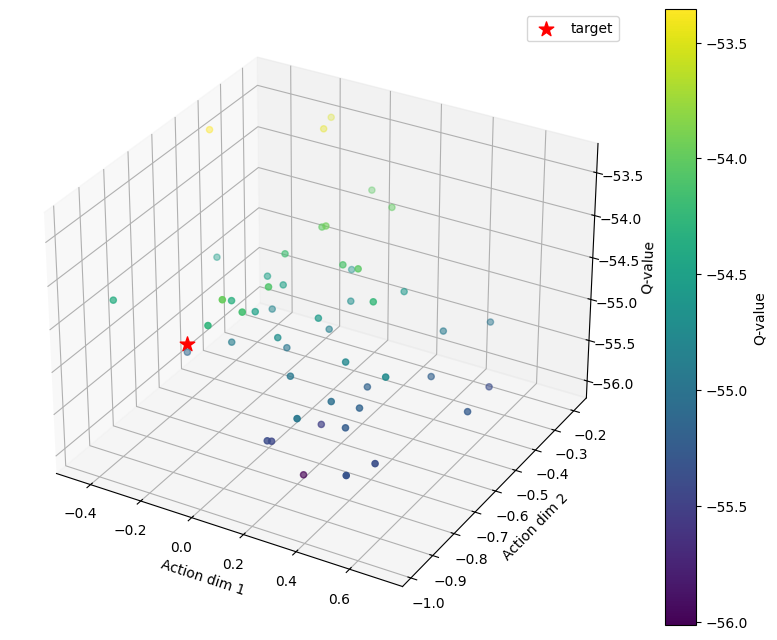

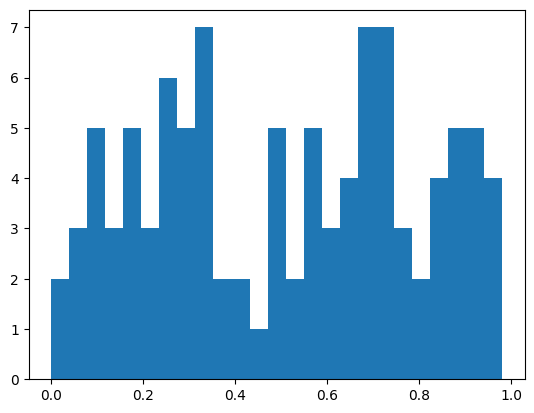

Number of top 5% quantile points: 4


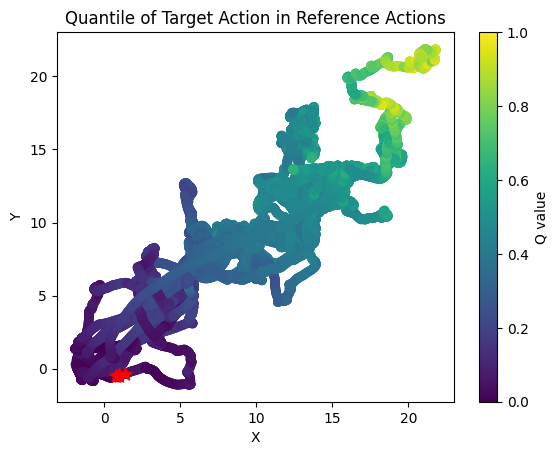

In [15]:
# 3D scatter plot of reference actions and q-values. Color points by q-value.
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8), dpi=100)
ax = fig.add_subplot(111, projection='3d')


target_idx = 3
ref_qs = ref_qs_list[target_idx]
ref_actions = ref_actions_list[target_idx]
target_action = target_actions_list[target_idx]
target_q = target_q_list[target_idx]

correlations = []
for dim in range(ref_actions.shape[1]):
    corr = np.corrcoef(ref_actions[:, dim], ref_qs)[0, 1]
    correlations.append(corr)
correlations = np.array(correlations)
abs_corr = np.abs(correlations)
top2_dims = abs_corr.argsort()[-2:][::-1]
print(f"Top 2 most correlated action dims with q: {top2_dims}, correlations: {correlations[top2_dims]}")

action_dim1, action_dim2 = top2_dims[0], top2_dims[1]
# action_dim1, action_dim2 = 0, 1

# Use first two action dimensions for the x and y axes, q-value for z and color.
sc = ax.scatter(
    ref_actions[:, action_dim1],                        # x-axis: action dim 1
    ref_actions[:, action_dim2],                        # y-axis: action dim 2
    ref_qs,                                             # z-axis: q-value
    c=ref_qs,                                           # color by q value
    cmap='viridis'
)

print(ref_qs.min(), ref_qs.mean(), ref_qs.max())
print(target_q)

# Compute the quantile of target_q within ref_qs (i.e., its percentile location)
quantile = (ref_qs < target_q).mean()
print("Quantile Statistics:")
print(f"Min: {quantiles.min()}, Mean: {quantiles.mean()}, Median: {np.median(quantiles)}, Max: {quantiles.max()}, Std: {quantiles.std()}")

# Plot the target action
ax.scatter(
    target_action[action_dim1], target_action[action_dim2], target_q,
    color='red', marker='*', s=120, label='target'
)

ax.set_xlabel('Action dim 1')
ax.set_ylabel('Action dim 2')
ax.set_zlabel('Q-value')
plt.colorbar(sc, ax=ax, label='Q-value')
plt.legend()
plt.show()

# Plot the quantiles
plt.hist(quantiles, bins=25)
plt.show()


# Find the indices where the quantile is in the top 5%
top5_indices = np.where(quantiles > 0.95)[0]
print(f"Number of top 5% quantile points: {len(top5_indices)}")


top5_locations = success_states[top5_indices, :2]
all_locations = success_states[:, :2]

plt.scatter(all_locations[:, 0], all_locations[:, 1], c=all_q_values, cmap='viridis')
plt.scatter(top5_locations[:, 0], top5_locations[:, 1], c='red', marker='*', s=100)
plt.colorbar(label='Q value')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Quantile of Target Action in Reference Actions')
plt.show()

### Guided Model

In [231]:
# ============================================================================
# IMPORTANT: Reset RNG state for consistent evaluation (matching guidance_evaluation.py)
# ============================================================================
random.seed(seed)
np.random.seed(seed)

guidance_coeff = 0.5
partial_guidance = 9
master_key = jax.random.PRNGKey(int(seed))

# Call eval_guidance with master_key (matching guidance_evaluation.py)
guided_stats, guided_trajs, guided_vels_by_episode, guided_gradient_vals_by_episode, guided_actions_list, guided_clean_preds_by_episode = eval_guidance(
    agent=fbrac_agent,
    config=fbrac_config,
    env=fbrac_eval_env,
    energy_fn=energy_fn,
    num_eval_episodes=10,
    eval_temperature=0,  # Explicitly set to 0 for determinism
    guidance_coeff=guidance_coeff,
    partial_guidance=partial_guidance,
    seed=seed,
    key=master_key,  # Already using master_key - good!
)

print(f"\n✓ Evaluation complete with guidance_coeff={guidance_coeff}, partial_guidance={partial_guidance}")
guided_stats

JIT-compiling guided actor function for coeff=0.5...


Evaluating coeff=0.5: 100%|██████████| 10/10 [01:02<00:00,  6.27s/it]



✓ Evaluation complete with guidance_coeff=0.5, partial_guidance=9


defaultdict(list,
            {'xy': 12.275887886344087,
             'prev_qpos': 0.6417926493253556,
             'prev_qvel': -0.5382250592448081,
             'qpos': 0.6288268406057351,
             'qvel': -0.5016581608234592,
             'success': 0.0,
             'total.timesteps': 195414.0,
             'episode.final_reward': -1.0,
             'episode.return': -2000.0,
             'episode.length': 2000.0,
             'episode.duration': 6.268051981925964})

In [232]:
guided_success_idx, guided_failure_idx = get_success_failure_idx(guided_trajs)

try:
    guided_success_states = np.concatenate([np.array(x['observation']) for x in np.array(guided_trajs)[guided_success_idx]], axis=0)
    guided_success_actions = np.concatenate([np.array(x['action']) for x in np.array(guided_trajs)[guided_success_idx]], axis=0)
except:
    guided_success_states = np.concatenate([np.array(x['observation']) for x in np.array(guided_trajs)[guided_failure_idx]], axis=0)
    guided_success_actions = np.concatenate([np.array(x['action']) for x in np.array(guided_trajs)[guided_failure_idx]], axis=0)
guided_all_q_values = compute_q_values(fbrac_agent, guided_success_states, guided_success_actions, batch_size=256)

num_states = 100 # number of states to evaluate
num_samples = 50 # number of ref model generations per state
ref_actions_list, ref_qs_list, target_actions_list, target_q_list, quantiles = compute_ref_target_q_values(
    fbrac_agent, 
    guided_success_states,
    guided_success_actions,
    num_states=num_states,
    num_samples=num_samples,
    key=jax.random.PRNGKey(int(seed)),)

100%|██████████| 79/79 [00:05<00:00, 14.89it/s]


(20000,)


100%|██████████| 100/100 [00:12<00:00,  7.97it/s]


Quantile Statistics:
Min: 0.019999999552965164, Mean: 0.7511999011039734, Median: 0.8399999737739563, Max: 1.0, Std: 0.22846128046512604


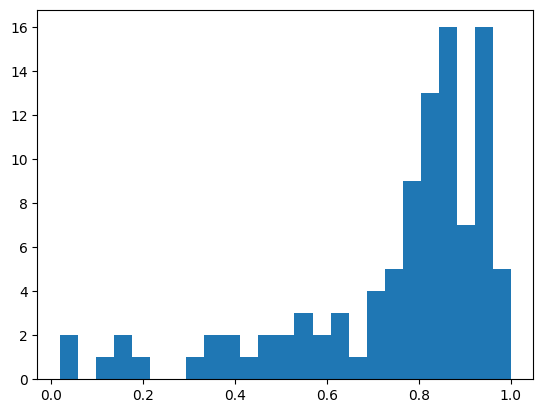

Number of top 5% quantile points: 94


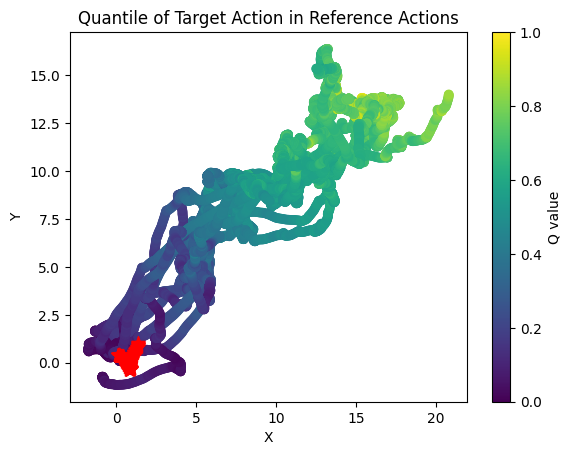

Top 2 most correlated action dims with q: [2 6], correlations: [0.5487236  0.54510531]
-108.97347 -107.9502 -107.621864 0.20730172 1.3516083
[-107.752525]
Quantile of target_q in ref_qs: 0.900


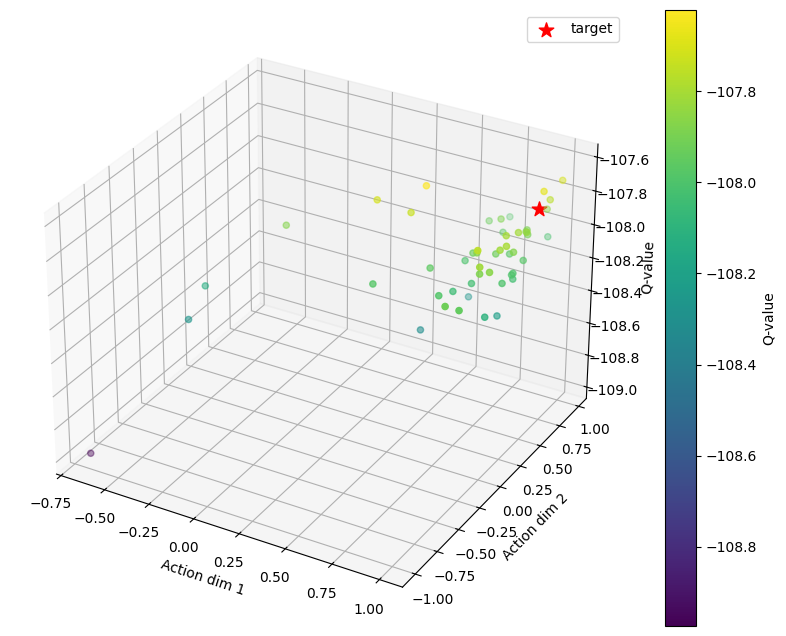

In [233]:
# ====== Quantile Histogram ======
# Plot the quantiles
print("Quantile Statistics:")
print(f"Min: {quantiles.min()}, Mean: {quantiles.mean()}, Median: {np.median(quantiles)}, Max: {quantiles.max()}, Std: {quantiles.std()}")
plt.hist(quantiles, bins=25)
plt.show()



# ====== Location Scatter Plot with Q-values ======
# Find the indices where the quantile is in the top 5%
top5_indices = np.where(quantiles > 0.2)[0]
print(f"Number of top 5% quantile points: {len(top5_indices)}")


top5_locations = guided_success_states[top5_indices, :2]
all_locations = guided_success_states[:, :2]

plt.scatter(all_locations[:, 0], all_locations[:, 1], c=guided_all_q_values, cmap='viridis')
plt.scatter(top5_locations[:, 0], top5_locations[:, 1], c='red', marker='*', s=100)
plt.colorbar(label='Q value')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Quantile of Target Action in Reference Actions')
plt.show()


# ====== 3D Scatter Plot of Reference Actions and Q-values Along specified dimensions======
fig = plt.figure(figsize=(10, 8), dpi=100)
ax = fig.add_subplot(111, projection='3d')

# Select the target_idx based on the quantile value
lower_bound = 0.5
upper_bound = 1.0
selection_condition = (quantiles > lower_bound) & (quantiles <= upper_bound)
target_idx = np.random.choice(np.where(selection_condition)[0])

ref_qs = ref_qs_list[target_idx]
ref_actions = ref_actions_list[target_idx]
target_action = target_actions_list[target_idx]
target_q = target_q_list[target_idx]

correlations = []
for dim in range(ref_actions.shape[1]):
    corr = np.corrcoef(ref_actions[:, dim], ref_qs)[0, 1]
    correlations.append(corr)
correlations = np.array(correlations)
abs_corr = np.abs(correlations)
top2_dims = abs_corr.argsort()[-2:][::-1]
print(f"Top 2 most correlated action dims with q: {top2_dims}, correlations: {correlations[top2_dims]}")

action_dim1, action_dim2 = top2_dims[0], top2_dims[1]
# action_dim1, action_dim2 = 0, 1

# Use first two action dimensions for the x and y axes, q-value for z and color.
sc = ax.scatter(
    ref_actions[:, action_dim1],                        # x-axis: action dim 1
    ref_actions[:, action_dim2],                        # y-axis: action dim 2
    ref_qs,                                             # z-axis: q-value
    c=ref_qs,                                           # color by q value
    cmap='viridis'
)

print(ref_qs.min(), ref_qs.mean(), ref_qs.max(), ref_qs.std(), ref_qs.max() - ref_qs.min())
print(target_q)

# Compute the quantile of target_q within ref_qs (i.e., its percentile location)
quantile = (ref_qs < target_q).mean()
print(f"Quantile of target_q in ref_qs: {quantile:.3f}")

# Plot the target action
ax.scatter(
    target_action[action_dim1], target_action[action_dim2], target_q,
    color='red', marker='*', s=120, label='target'
)

ax.set_xlabel('Action dim 1')
ax.set_ylabel('Action dim 2')
ax.set_zlabel('Q-value')
plt.colorbar(sc, ax=ax, label='Q-value')
plt.legend()
plt.show()

### Gradient Analysis

In [236]:
task_idx = 0

np.random.seed(seed)

guidance_coeff = 0.5
partial_guidance = 9

flow_steps = 10
gradient_vals = guided_gradient_vals_by_episode[task_idx]
gradient_vals = np.array(gradient_vals)


extracted_guidance_vals = []
for t in trange(len(gradient_vals)):
    sampling_traj = guidance_coeff * gradient_vals[t,-partial_guidance:] / flow_steps
    extracted_guidance_vals.append(sampling_traj)

extracted_guidance_vals = np.array(extracted_guidance_vals)
extracted_guidance_vals.shape

100%|██████████| 2000/2000 [00:00<00:00, 262941.04it/s]


(2000, 9, 21)

In [235]:
extracted_guidance_vals[1600]

array([[-1.85604487e-03, -6.10639853e-03,  1.18447812e-02,
        -1.24553835e-03,  3.15843010e-03,  1.56818256e-02,
        -1.83186156e-03,  9.06111021e-03,  3.69061227e-03,
        -2.32205167e-03, -4.99749742e-03, -2.20032278e-02,
         1.00245355e-02, -5.55918878e-03,  5.21685695e-03,
         4.26957384e-03, -3.08533162e-02, -7.98379711e-04,
         4.79178829e-03, -1.39795570e-02,  5.37482090e-03],
       [-1.02460326e-03, -6.07912382e-03,  1.18622109e-02,
        -1.45956315e-03,  3.16824461e-03,  1.56775974e-02,
        -1.35119876e-03,  9.23666079e-03,  4.09317017e-03,
        -2.63279094e-03, -5.48122311e-03, -2.18128115e-02,
         9.22469795e-03, -5.27845789e-03,  4.84767137e-03,
         4.45540529e-03, -3.12521532e-02, -6.20734529e-04,
         4.70317062e-03, -1.43923489e-02,  5.22001367e-03],
       [-6.60353326e-05, -6.22160733e-03,  1.22647900e-02,
        -1.79769879e-03,  3.25841084e-03,  5.90615161e-03,
        -7.51170795e-04,  9.91404522e-03,  4.61926311e

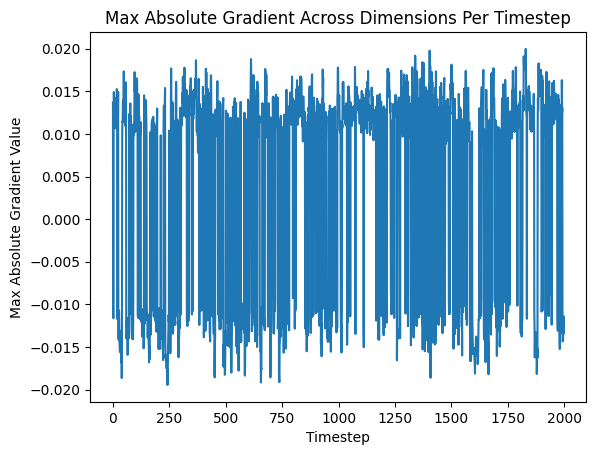

In [239]:
# Plot gradient along the dimension where the absolute value is the largest for each timestep
idx = 4

# Find the index (dimension) with the maximum absolute value at each timestep
max_abs_dim_idxs = np.argmax(np.abs(extracted_guidance_vals[:,idx,:]), axis=1)
# Gather the corresponding max-gradients at each timestep
max_abs_grads = extracted_guidance_vals[np.arange(len(extracted_guidance_vals)), idx, max_abs_dim_idxs]

plt.plot(max_abs_grads)
plt.title("Max Absolute Gradient Across Dimensions Per Timestep")
plt.xlabel("Timestep")
plt.ylabel("Max Absolute Gradient Value")
plt.show()

In [78]:
# guided_actions_list[0]
# guided_clean_preds_by_episode[0]
# guided_gradient_vals_by_episode[0]
# guided_vels_by_episode[0]

t = 1700

np_guided_actions_list = np.array(guided_actions_list[task_idx])
np_guided_clean_preds_by_episode = np.array(guided_clean_preds_by_episode[task_idx])
np_guided_gradient_vals_by_episode = np.array(guided_gradient_vals_by_episode[task_idx])
np_guided_vels_by_episode = np.array(guided_vels_by_episode[task_idx])

np_observations = np.array(guided_trajs[task_idx]['observation'])
np_actions = np.array(guided_trajs[task_idx]['action'])

def get_ref_action(agent, observation, init_noise, flow_steps):
    ref_action = init_noise

    noisy_qs = []

    for i in range(flow_steps):
        t = jnp.full((*observation.shape[:-1], 1), i / flow_steps)
        vels = agent.network.select('actor_bc_flow')(observation, ref_action, t)
        ref_action = ref_action + vels / flow_steps
        noisy_q = agent.network.select('critic')(observation, ref_action).mean(axis=0)
        noisy_qs.append(noisy_q)

    ref_action = jnp.clip(ref_action, -1, 1)

    
    return ref_action

def compare_clean_pred(agent, observation, target_action, clean_preds):
    ref_q = agent.network.select('critic')(observation, target_action).mean(axis=0)
    for i in range(clean_preds.shape[0]):
        clean_pred = clean_preds[i,...]
        clean_pred_q = agent.network.select('critic')(observation, clean_pred).mean(axis=0)
        print(f"t: {i}, clean_pred_q: {clean_pred_q}, ref_q: {ref_q}")


ref_action = get_ref_action(fbrac_agent, np_observations[t,...], np_guided_actions_list[t,0,...],flow_steps)
ref_q = fbrac_agent.network.select('critic')(np_observations[t,...], ref_action).mean(axis=0)


# Compare clean prediction with true reference action (Quantitatively see the approximation error of one-step clean prediction)
compare_clean_pred(fbrac_agent, np_observations[t,...].reshape(1,-1), ref_action, np_guided_clean_preds_by_episode[t,...])
guided_action_q = fbrac_agent.network.select('critic')(np_observations[t,...], np_actions[t,...]).mean(axis=0)


print(ref_action)

print("--------------------------------")

print(np_actions[t,...], guided_action_q)


# Sample "num_samples" number of actions from the reference action distribution
num_samples = 50
n_observations = np_observations[t,...].reshape(1,-1).repeat(num_samples, axis=0)
ref_sampled_actions = fbrac_agent.sample_actions(n_observations, seed=jax.random.PRNGKey(int(seed)))
ref_sampled_qs = fbrac_agent.network.select('critic')(n_observations, ref_sampled_actions).mean(axis=0)


# 3D Scatter plot of reference action, guided action, and extra sampled actions
# Values you have to plot are ref_action (ref_q), np_actions[t,...] (guided_action_q), ref_sampled_actions (ref_sampled_qs)
fig = plt.figure(figsize=(10, 8), dpi=100)
ax = fig.add_subplot(111, projection='3d')

# With ref_sampled_qs, find the top 2 most correlated action dims with q
correlations = []
for dim in range(ref_sampled_actions.shape[1]):
    corr = np.corrcoef(ref_sampled_actions[:, dim], ref_sampled_qs)[0, 1]
    correlations.append(corr)
correlations = np.array(correlations)
action_dim1, action_dim2 = np.argsort(correlations)[-2:][::-1]


# Plot sampled actions
ax.scatter(
    ref_sampled_actions[:, action_dim1],
    ref_sampled_actions[:, action_dim2],
    ref_sampled_qs,
    c=ref_sampled_qs,
    cmap='viridis',
    s=50,
    alpha=0.8,
    label='Sampled actions'
)

# Plot reference action
ax.scatter(
    ref_action[action_dim1],
    ref_action[action_dim2],
    ref_q,
    color='red',
    marker='*',
    s=200,
    label='Reference action'
)

# Plot guided action
ax.scatter(
    np_actions[t, action_dim1],
    np_actions[t, action_dim2],
    guided_action_q,
    color='black',
    marker='X',
    s=150,
    label='Guided action'
)

ax.set_xlabel('Action dim 1')
ax.set_ylabel('Action dim 2')
ax.set_zlabel('Q-value')
plt.colorbar(ax.collections[0], ax=ax, label='Q-value')
plt.legend()
plt.show()


NameError: name 'guided_actions_list' is not defined

In [51]:
# Compare the reference action and guided action for all t steps, remove ref_sampling

np_guided_actions_list = np.array(guided_actions_list[task_idx])
np_guided_clean_preds_by_episode = np.array(guided_clean_preds_by_episode[task_idx])
np_guided_gradient_vals_by_episode = np.array(guided_gradient_vals_by_episode[task_idx])
np_guided_vels_by_episode = np.array(guided_vels_by_episode[task_idx])

np_observations = np.array(guided_trajs[task_idx]['observation'])
np_actions = np.array(guided_trajs[task_idx]['action'])

def get_ref_action(agent, observation, init_noise, flow_steps):
    ref_action = init_noise
    for i in range(flow_steps):
        t = jnp.full((*observation.shape[:-1], 1), i / flow_steps)
        vels = agent.network.select('actor_bc_flow')(observation, ref_action, t)
        ref_action = ref_action + vels / flow_steps

    ref_action = jnp.clip(ref_action, -1, 1)
    return ref_action

def compare_clean_pred(agent, observation, target_action, clean_preds):
    ref_q = agent.network.select('critic')(observation, target_action).mean(axis=0)
    for i in range(clean_preds.shape[0]):
        clean_pred = clean_preds[i,...]
        clean_pred_q = agent.network.select('critic')(observation, clean_pred).mean(axis=0)
        print(f"t: {i}, clean_pred_q: {clean_pred_q}, ref_q: {ref_q}")

# We'll compare for all timesteps t in the episode

flow_steps = np_guided_vels_by_episode.shape[1] if np_guided_vels_by_episode.ndim == 3 else np_guided_vels_by_episode.shape[0]
num_steps = np_observations.shape[0]
action_dim = np_actions.shape[1]

ref_actions = []
ref_qs = []
guided_action_qs = []
# Set the batch size
batch_size = 256

# Prepare arrays for batch computation
ref_actions = []
ref_qs = []
guided_action_qs = []

num_batches = int(np.ceil(num_steps / batch_size))

for batch_idx in tqdm(range(num_batches)):
    start = batch_idx * batch_size
    end = min((batch_idx + 1) * batch_size, num_steps)

    # Slicing for current batch
    batch_observations = np_observations[start:end]
    batch_guided_actions_0 = np_guided_actions_list[start:end, 0, ...]
    batch_guided_vels = np_guided_vels_by_episode[start:end]
    batch_actions = np_actions[start:end]

    # Compute ref_actions for the batch
    # We loop for get_ref_action because flow_steps might differ (if batching is not possible)
    batch_ref_actions = []
    for i in range(end - start):
        ref_action = get_ref_action(
            fbrac_agent,
            batch_observations[i],
            batch_guided_actions_0[i],
            flow_steps
        )
        batch_ref_actions.append(np.array(ref_action))
    batch_ref_actions = np.stack(batch_ref_actions, axis=0)
    
    # Compute Q-values (batched if possible)
    # Try batch inference for critic if supported
    batch_ref_qs = fbrac_agent.network.select('critic')(batch_observations, batch_ref_actions).mean(axis=0)
    batch_guided_action_qs = fbrac_agent.network.select('critic')(batch_observations, batch_actions).mean(axis=0)

    ref_actions.append(batch_ref_actions)
    ref_qs.append(np.array(batch_ref_qs))
    guided_action_qs.append(np.array(batch_guided_action_qs))

ref_actions = np.concatenate(ref_actions, axis=0)
ref_qs = np.concatenate(ref_qs, axis=0)
guided_action_qs = np.concatenate(guided_action_qs, axis=0)

# Plot the advantage of guided action q over ref_q across all timesteps
advantage_q = guided_action_qs - ref_qs

plt.figure(figsize=(10, 5))
plt.plot(advantage_q, label='Advantage (guided_q - ref_q)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Timestep')
plt.ylabel('Q(Guided Action) - Q(Reference Action)')
plt.title('Advantage of Guided Action Q-value over Reference Q-value')
plt.legend()
plt.tight_layout()
plt.show()

# Optionally: print some statistics of difference
mae = np.mean(np.abs(ref_actions - np_actions), axis=0)

  0%|          | 0/8 [00:24<?, ?it/s]


KeyboardInterrupt: 

In [34]:
advantage_q.min(), advantage_q.mean(), advantage_q.max(), advantage_q.std()

(-15.687061, 0.6310704, 13.736275, 1.4626431)

## DQL Analysis

In [ ]:
dql_task_idx = 2
dql_env_name = f"antmaze-large-navigate-singletask-task{dql_task_idx}-v0"
# dql_env_name = f"humanoidmaze-medium-navigate-singletask-task{dql_task_idx}-v0"
dql_seed = 0
buffer_size = 2000000
eval_episodes = 10

# Initialize random seeds
random.seed(dql_seed)
np.random.seed(dql_seed)

# DQL Training hyperparameters (from run_dql_pipeline.sh)
dql_alpha = 30
dql_diffusion_steps = 10
dql_q_agg = "mean"
dql_reward_discount = 0.99
dql_use_value_layer_norm = True
dql_use_actor_layer_norm = False
dql_offline_steps = 1000000


env, eval_env, train_dataset, val_dataset = make_env_and_datasets(dql_env_name, frame_stack=None)
train_dataset = Dataset.create(**train_dataset)
train_dataset = ReplayBuffer.create_from_initial_dataset(
    dict(train_dataset), size=max(buffer_size, train_dataset.size + 1)
)

example_batch = train_dataset.sample(1)

# Build DQL experiment name and path (following run_dql_pipeline.sh pattern)
dql_exp_name = f"{dql_env_name}_alpha{dql_alpha}-diff{dql_diffusion_steps}-qagg{dql_q_agg}-discount{dql_reward_discount}_sd{dql_seed:03d}"


print(dql_exp_name)

dql_base_dir = "exp"
dql_run_group = dql_env_name
dql_agent_path = f"{dql_base_dir}/dql/{dql_run_group}/{dql_exp_name}"
dql_restore_epoch = dql_offline_steps

# Load DQL agent config (following guidance_evaluation.py pattern)
import importlib.util
dql_agent_config_path = "agents/dql.py"
dql_spec = importlib.util.spec_from_file_location("dql_agent_config", dql_agent_config_path)
dql_agent_config_module = importlib.util.module_from_spec(dql_spec)
dql_spec.loader.exec_module(dql_agent_config_module)
dql_config = dql_agent_config_module.get_config()

# Set DQL hyperparameters in config (following run_dql_pipeline.sh pattern)
dql_config.alpha = dql_alpha
dql_config.diffusion_steps = dql_diffusion_steps
dql_config.q_agg = dql_q_agg
dql_config.discount = dql_reward_discount
dql_config.layer_norm = dql_use_value_layer_norm
dql_config.actor_layer_norm = dql_use_actor_layer_norm

# Create DQL agent (following guidance_evaluation.py pattern)
dql_agent_class = agents[dql_config['agent_name']]
dql_agent = dql_agent_class.create(
    dql_seed,
    example_batch['observations'],
    example_batch['actions'],
    dql_config,
)

# Restore DQL agent (following guidance_evaluation.py pattern)
if dql_agent_path and dql_restore_epoch:
    dql_agent = restore_agent(dql_agent, dql_agent_path, dql_restore_epoch)
    print(f"DQL agent restored from {dql_agent_path} at epoch {dql_restore_epoch}")

print("DQL model loaded successfully!")


antmaze-large-navigate-singletask-task2-v0_alpha30-diff10-qaggmean-discount0.99_sd000
Restored from exp/dql/antmaze-large-navigate-singletask-task2-v0/antmaze-large-navigate-singletask-task2-v0_alpha30-diff10-qaggmean-discount0.99_sd000/params_1000000.pkl
DQL agent restored from exp/dql/antmaze-large-navigate-singletask-task2-v0/antmaze-large-navigate-singletask-task2-v0_alpha30-diff10-qaggmean-discount0.99_sd000 at epoch 1000000
DQL model loaded successfully!


In [139]:
import jax.numpy as jnp
from tqdm import trange


def sample_action_with_guidance(
        agent,
        observations,
        energy_fn,
        seed=None,
        guidance_coeff=1.0,
        temperature=1.0,
        partial_guidance=-1,
    ):
    """
    Sample actions from the policy with energy-based guidance.
    
    Args:
        observations: Current observations
        energy_fn: Energy function that takes (observations, actions) and returns energy values
        seed: Random seed for sampling
        guidance_coeff: Guidance strength coefficient
        temperature: Sampling temperature
        partial_guidance: If -1, apply guidance for entire sampling process.
                        If > 0 and < flow_steps, apply guidance only to last {partial_guidance} steps.
        
    Returns:
        actions: Sampled actions with guidance applied
        energy_vals: List of energy values computed during sampling
        gradient_vals: List of gradient values computed during sampling
        cosine_sim_vals: List of cosine similarity values between Q-gradient and safety gradient
    """
    
    # In place condition for experiment purpose
    rescale_strategy = "normalize" # to be move to guidance_evaluation main function
    pred_clean = True
    guidance_scheduling = "fixed"
    last_step_guidance = True

    def get_guidance_strength(i, exp_k=5):
        """
        Treat the guidance_coeff as max strength
        """
        min_guidance = 0.0

        if guidance_scheduling == "fixed":
            return guidance_coeff
        elif guidance_scheduling == "neg_linear": # start from guidance_coeff and decrease linearly
            return guidance_coeff - (guidance_coeff - min_guidance) * (i+1) / flow_steps
        elif guidance_scheduling == "linear":
            return min_guidance + (guidance_coeff - min_guidance) * (i+1) / flow_steps
        elif guidance_scheduling == "exp":
            factor = (jnp.exp((i+1) * exp_k / flow_steps) - 1) / (jnp.exp(exp_k) - 1)
            return min_guidance + (guidance_coeff - min_guidance) * factor
        else:
            raise ValueError(f"Invalid guidance_scheduling: {guidance_scheduling}")

    # Original fixed guidance coefficient method
    drifts_list = [] # model prediction for each step
    gradient_vals = []
    clean_preds = []
    actions_list = []
    action_seed, noise_seed = jax.random.split(seed)
    noises = jax.random.normal(
        action_seed,
        (
            *observations.shape[: -len(agent.config['ob_dims'])],
            agent.config['action_dim'],
        ),
    )
    actions = noises

    diffusion_steps = agent.config['diffusion_steps']

    # Determine guidance start/end in forward indexing
    if partial_guidance == -1:
        guidance_start_step = 0
        guidance_end_step = diffusion_steps
    elif 0 < partial_guidance < diffusion_steps:
        # Apply guidance only to last {partial_guidance} steps
        guidance_start_step = 0
        guidance_end_step = partial_guidance
    else:
        guidance_start_step = 0
        guidance_end_step = 0
        print(f"Warning: Invalid partial_guidance value {partial_guidance}. Using no guidance.")
    
    # Pre-compile the gradient function once for better performance (only if we'll use guidance)
    energy_grad_fn = None
    if guidance_end_step > 0:
        try:
            energy_grad_fn = agent._get_energy_grad_fn(energy_fn)
        except Exception as e:
            print(f"Error pre-compiling gradient function: {e}")
            energy_grad_fn = None

    # Apply DDPM steps with conditional guidance
    for i in range(diffusion_steps)[::-1]:
        t = jnp.full((*observations.shape[:-1], 1), i / diffusion_steps)
        t_int = jnp.full((*observations.shape[:-1], 1), i)

        betas = agent.extract(agent.betas, t_int, actions.shape)
        sqrt_alphas = agent.extract(agent.sqrt_alphas, t_int, actions.shape)
        sqrt_alphas_cumprod = agent.extract(agent.sqrt_alphas_cumprod, t_int, actions.shape)
        sqrt_one_minus_alphas_cumprod = agent.extract(agent.sqrt_one_minus_alphas_cumprod, t_int, actions.shape)
        
        preds = agent.network.select('actor_diffusion')(observations, actions, t)

        # Split seed BEFORE generating noise
        noise_seed, step_noise_seed = jax.random.split(noise_seed)
        step_noise = jax.random.normal(
                step_noise_seed,
                (
                    *observations.shape[: -len(agent.config['ob_dims'])],
                    agent.config['action_dim'],
                ),
            )

        # Don't add noise in the final step (i=0)
        noise_scale = jnp.where(i > 0, jnp.sqrt(betas), 0.0)

        guidance_weight = get_guidance_strength(i)

        # Only compute guidance if guidance_coeff is not zero
        # Use JAX conditional operations for JIT compatibility
        def apply_guidance():
            if energy_grad_fn is not None:
                # Compute Q value at target_actions (a_0), but gradient w.r.t. a_t
                def q_fn_at_target(a_t):
                    if pred_clean:
                        # Compute a_0 from a_t
                        a_0 = (a_t - sqrt_one_minus_alphas_cumprod * preds) / sqrt_alphas_cumprod
                    else:
                        a_0 = a_t
                    qs = agent.network.select('critic')(observations, a_0)
                    return jnp.mean(qs)
                
                q_grad = jax.grad(q_fn_at_target)(actions)  # Gradient w.r.t. a_t

                guidance_grad = q_grad

                if rescale_strategy == "normalize":
                    # normalize
                    guidance_grad = guidance_grad * jnp.linalg.norm(preds) / jnp.linalg.norm(guidance_grad)
                
                return guidance_grad, 0.0
            else:
                return jnp.zeros_like(preds), 0.0
        
        def no_guidance():
            return jnp.zeros_like(preds), 0.0
        
        should_apply = (guidance_coeff != 0.0 and
                        i >= guidance_start_step and
                        i < guidance_end_step and
                        energy_grad_fn is not None)
        
        # Use JAX conditional to choose guidance or no guidance
        guidance_grad, _ = jax.lax.cond(
            should_apply,
            apply_guidance,
            no_guidance
        )

        guidance_grad = jnp.where(
            jnp.isnan(guidance_grad) | jnp.isinf(guidance_grad),
            0.0,
            guidance_grad
        )
        guidance_grad = jnp.clip(guidance_weight*guidance_grad, -1, 1)

        gradient_vals.append(guidance_grad)
        drifts_list.append(preds) # model prediction for each step
        a_0 = (actions - sqrt_one_minus_alphas_cumprod * preds) / sqrt_alphas_cumprod
        a_0 = jnp.clip(a_0, -1, 1)
        clean_preds.append(a_0) # one-step clean action prediction
        actions_list.append(actions) # current action for each step
        guided_preds = preds - guidance_grad
        actions_guided = actions / sqrt_alphas - betas / (sqrt_alphas * sqrt_one_minus_alphas_cumprod) * guided_preds

        actions = actions_guided + noise_scale * step_noise

    actions = jnp.clip(actions, -1, 1)
    return actions, drifts_list, gradient_vals, clean_preds, actions_list

In [140]:
def eval_guidance(
    agent,
    env,
    energy_fn,
    config=None,
    num_eval_episodes=50,
    eval_temperature=0,
    guidance_coeff=1.0,
    partial_guidance=-1,
    seed=0,
    key=None,
):
    """Evaluate the agent in the environment using guided sampling.

    Args:
        agent: Agent with sample_action_with_guidance method.
        env: Environment.
        energy_fn: Energy function for guidance.
        config: Configuration dictionary.
        num_eval_episodes: Number of episodes to evaluate the agent.
        eval_temperature: Action sampling temperature.
        guidance_coeff: Guidance strength coefficient.
        partial_guidance: If -1, apply guidance for entire sampling process.
                         If > 0 and < flow_steps, apply guidance only to last {partial_guidance} steps.

    Returns:
        A tuple containing the statistics, trajectories, energy values, gradient values, and lambda values.
    """
    from collections import defaultdict
    
    # Create guided actor function
    def guided_actor_fn(observations, seed=None, temperature=eval_temperature):
        # Use regular fixed coefficient guidance method
        return sample_action_with_guidance(
            agent=agent,
            observations=observations,
            energy_fn=energy_fn,
            seed=seed,
            guidance_coeff=guidance_coeff,
            temperature=temperature,
            partial_guidance=partial_guidance
        )

    print(f"JIT-compiling guided actor function for coeff={guidance_coeff}...")
    if key is None:
        key = jax.random.PRNGKey(int(seed))
    guided_actor_fn = jax.jit(guided_actor_fn)
    trajs = []
    stats = defaultdict(list)
    energy_vals_by_episode = []
    gradient_vals_by_episode = []
    lambda_vals_by_episode = []
    cosine_sim_vals_by_episode = []

    for i in trange(num_eval_episodes, desc=f"Evaluating coeff={guidance_coeff}"):
        key, ep_key = jax.random.split(key)
        traj = defaultdict(list)
        energy_vals_list = []
        gradient_vals_list = []
        lambda_vals_list = []
        cosine_sim_vals_list = []
        observation, info = env.reset(seed=i)
        done = False
        step = 0
        while not done:
            ep_key, action_key = jax.random.split(ep_key)
            result = guided_actor_fn(observations=observation, temperature=eval_temperature, seed=action_key)
            # Handle different return formats based on guidance method
            if isinstance(result, tuple) and len(result) == 5:
                # Covariance method returns (action, energy_vals, gradient_vals, lambda_vals, cosine_sim_vals)
                action, energy_vals, gradient_vals, lambda_vals, cosine_sim_vals = result
                energy_vals_list.append(energy_vals)
                gradient_vals_list.append(gradient_vals)
                lambda_vals_list.append(lambda_vals)
                cosine_sim_vals_list.append(cosine_sim_vals)
            elif isinstance(result, tuple) and len(result) == 4:
                # Regular method returns (action, energy_vals, gradient_vals, cosine_sim_vals)
                action, energy_vals, gradient_vals, cosine_sim_vals = result
                energy_vals_list.append(energy_vals)
                gradient_vals_list.append(gradient_vals)
                cosine_sim_vals_list.append(cosine_sim_vals)
                # Create dummy lambda values if not provided
                lambda_vals_list.append([0.0])
            elif isinstance(result, tuple) and len(result) == 3:
                # Legacy format: (action, energy_vals, gradient_vals)
                action, energy_vals, gradient_vals = result
                energy_vals_list.append(energy_vals)
                gradient_vals_list.append(gradient_vals)
                # Create dummy lambda and cosine similarity values if not provided
                lambda_vals_list.append([0.0])
                cosine_sim_vals_list.append([0.0])
            elif isinstance(result, tuple) and len(result) == 2:
                action, energy_vals = result
                energy_vals_list.append(energy_vals)
                # Create dummy gradient, lambda, and cosine similarity values if not provided
                gradient_vals_list.append([jnp.zeros_like(observation)])
                lambda_vals_list.append([0.0])
                cosine_sim_vals_list.append([0.0])
            else:
                action = result
                # Create dummy energy, gradient, lambda, and cosine similarity values if not provided
                energy_vals_list.append(jnp.zeros(1))
                gradient_vals_list.append([jnp.zeros_like(observation)])
                lambda_vals_list.append([0.0])
                cosine_sim_vals_list.append([0.0])
            
            action = np.array(action)
            action = np.clip(action, -1, 1)

            next_observation, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            step += 1

            transition = dict(
                observation=observation,
                next_observation=next_observation,
                action=action,
                reward=reward,
                done=done,
                info=info,
            )
            from utils.evaluation import add_to
            add_to(traj, transition)
            observation = next_observation
        energy_vals_by_episode.append(energy_vals_list)
        gradient_vals_by_episode.append(gradient_vals_list)
        lambda_vals_by_episode.append(lambda_vals_list)
        cosine_sim_vals_by_episode.append(cosine_sim_vals_list)
        add_to(stats, flatten(info))
        trajs.append(traj)

    # Convert gradient values to regular Python lists for consistency
    def convert_nested_episodes(episodes):
        if episodes and len(episodes) > 0:
            converted_episodes = []
            for episode_vals in episodes:
                episode_list = []
                for val in episode_vals:
                    if hasattr(val, 'tolist'):
                        episode_list.append(val.tolist())
                    elif isinstance(val, (list, tuple)):
                        episode_list.append(list(val))
                    else:
                        episode_list.append(float(val))
                converted_episodes.append(episode_list)
            return converted_episodes
        else:
            return []

    gradient_vals_by_episode = convert_nested_episodes(gradient_vals_by_episode)
    energy_vals_by_episode = convert_nested_episodes(energy_vals_by_episode)
    cosine_sim_vals_by_episode = convert_nested_episodes(cosine_sim_vals_by_episode)
    lambda_vals_by_episode = convert_nested_episodes(lambda_vals_by_episode)

    for k, v in stats.items():
        stats[k] = np.mean(v)

    return stats, trajs, energy_vals_by_episode, gradient_vals_by_episode, lambda_vals_by_episode, cosine_sim_vals_by_episode

In [142]:
random.seed(dql_seed)
np.random.seed(dql_seed)
os.environ['PYTHONHASHSEED'] = str(dql_seed)
master_key = jax.random.PRNGKey(int(dql_seed))

guidance_coeff = 0.05
partial_guidance = 3

stats, trajs, drifts_by_episode, gradient_vals_by_episode, clean_preds_by_episode, actions_list = eval_guidance(
    agent=dql_agent,
    config=dql_config,
    env=eval_env,
    energy_fn=energy_fn,
    num_eval_episodes=50,
    guidance_coeff=guidance_coeff,
    partial_guidance=partial_guidance,
    seed=dql_seed,
    key=master_key,
)

stats

JIT-compiling guided actor function for coeff=0.05...


Evaluating coeff=0.05: 100%|██████████| 50/50 [01:37<00:00,  1.96s/it]


defaultdict(list,
            {'xy': 13.786843043329327,
             'prev_qpos': 1.8785913325667667,
             'prev_qvel': 0.019881092390746605,
             'qpos': 1.8822741062540882,
             'qvel': 0.028722907322328125,
             'success': 0.24,
             'total.timesteps': 270784.92,
             'episode.final_reward': -0.76,
             'episode.return': -969.02,
             'episode.length': 969.26,
             'episode.duration': 1.956552596092224})

In [95]:
trajs[0].keys()

dict_keys(['observation', 'next_observation', 'action', 'reward', 'done', 'info'])

In [143]:
success_idx, failure_idx = get_success_failure_idx(trajs)

try:
    success_states = np.concatenate([np.array(x['observation']) for x in np.array(trajs)[success_idx]], axis=0)
    success_actions = np.concatenate([np.array(x['action']) for x in np.array(trajs)[success_idx]], axis=0)
except:
    success_states = np.concatenate([np.array(x['observation']) for x in np.array(trajs)[failure_idx]], axis=0)
    success_actions = np.concatenate([np.array(x['action']) for x in np.array(trajs)[failure_idx]], axis=0)
all_q_values = compute_q_values(dql_agent, success_states, success_actions, batch_size=256)

num_states = 100 # number of states to evaluate
num_samples = 50 # number of ref model generations per state
ref_actions_list, ref_qs_list, target_actions_list, target_q_list, quantiles = compute_ref_target_q_values(
    dql_agent, 
    success_states,
    success_actions,
    num_states=num_states,
    num_samples=num_samples,
    key=jax.random.PRNGKey(int(dql_seed)),)

100%|██████████| 41/41 [00:06<00:00,  6.61it/s]


(10463,)


100%|██████████| 100/100 [00:13<00:00,  7.50it/s]


Quantile Statistics:
Min: 0.0, Mean: 0.6358000040054321, Median: 0.6499999761581421, Max: 1.0, Std: 0.24734258651733398


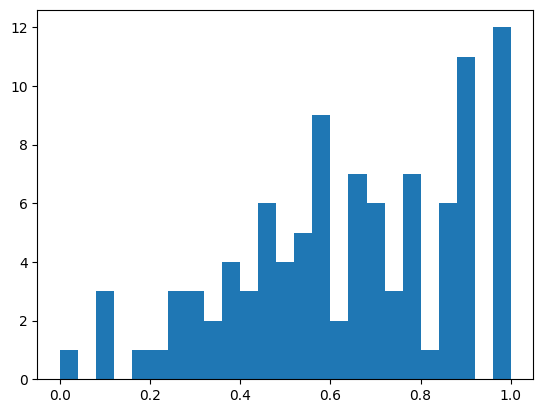

Number of top 5% quantile points: 95


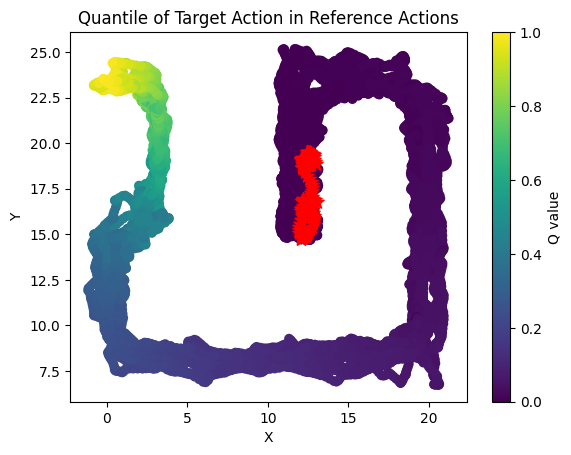

Top 2 most correlated action dims with q: [6 2], correlations: [-0.86229354  0.61717668]
-96.734695 -96.63449 -96.60294 0.0233748 0.13175201
[-96.61275]
Quantile of target_q in ref_qs: 0.900


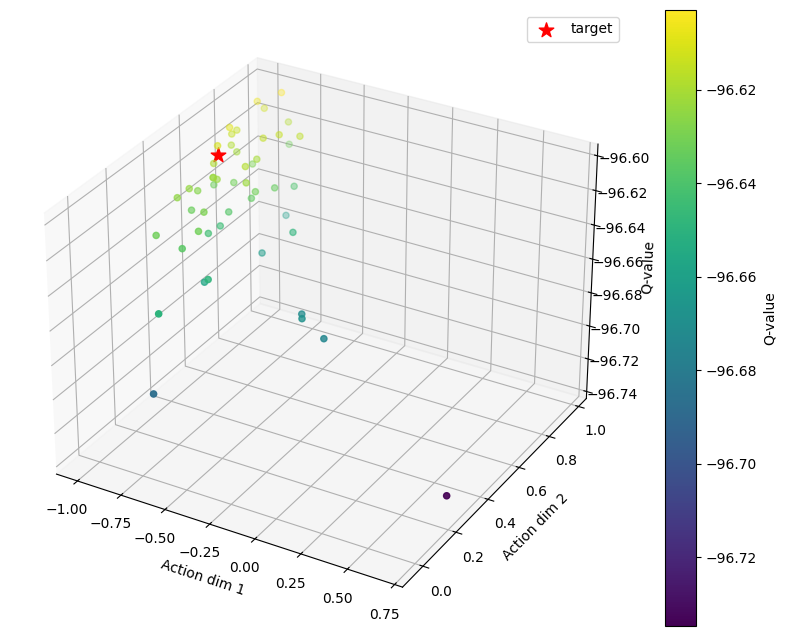

In [145]:
# ====== Quantile Histogram ======
# Plot the quantiles
print("Quantile Statistics:")
print(f"Min: {quantiles.min()}, Mean: {quantiles.mean()}, Median: {np.median(quantiles)}, Max: {quantiles.max()}, Std: {quantiles.std()}")
plt.hist(quantiles, bins=25)
plt.show()



# ====== Location Scatter Plot with Q-values ======
# Find the indices where the quantile is in the top 5%
top5_indices = np.where(quantiles > 0.2)[0]
print(f"Number of top 5% quantile points: {len(top5_indices)}")


top5_locations = success_states[top5_indices, :2]
all_locations = success_states[:, :2]

plt.scatter(all_locations[:, 0], all_locations[:, 1], c=all_q_values, cmap='viridis')
plt.scatter(top5_locations[:, 0], top5_locations[:, 1], c='red', marker='*', s=100)
plt.colorbar(label='Q value')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Quantile of Target Action in Reference Actions')
plt.show()


# ====== 3D Scatter Plot of Reference Actions and Q-values Along specified dimensions======
fig = plt.figure(figsize=(10, 8), dpi=100)
ax = fig.add_subplot(111, projection='3d')

# Select the target_idx based on the quantile value
lower_bound = 0.0
upper_bound = 1.0
selection_condition = (quantiles >= lower_bound) & (quantiles <= upper_bound)
target_idx = np.random.choice(np.where(selection_condition)[0])

ref_qs = ref_qs_list[target_idx]
ref_actions = ref_actions_list[target_idx]
target_action = target_actions_list[target_idx]
target_q = target_q_list[target_idx]

correlations = []
for dim in range(ref_actions.shape[1]):
    corr = np.corrcoef(ref_actions[:, dim], ref_qs)[0, 1]
    correlations.append(corr)
correlations = np.array(correlations)
abs_corr = np.abs(correlations)
top2_dims = abs_corr.argsort()[-2:][::-1]
print(f"Top 2 most correlated action dims with q: {top2_dims}, correlations: {correlations[top2_dims]}")

action_dim1, action_dim2 = top2_dims[0], top2_dims[1]
# action_dim1, action_dim2 = 0, 1

# Use first two action dimensions for the x and y axes, q-value for z and color.
sc = ax.scatter(
    ref_actions[:, action_dim1],                        # x-axis: action dim 1
    ref_actions[:, action_dim2],                        # y-axis: action dim 2
    ref_qs,                                             # z-axis: q-value
    c=ref_qs,                                           # color by q value
    cmap='viridis'
)

print(ref_qs.min(), ref_qs.mean(), ref_qs.max(), ref_qs.std(), ref_qs.max() - ref_qs.min())
print(target_q)

# Compute the quantile of target_q within ref_qs (i.e., its percentile location)
quantile = (ref_qs < target_q).mean()
print(f"Quantile of target_q in ref_qs: {quantile:.3f}")

# Plot the target action
ax.scatter(
    target_action[action_dim1], target_action[action_dim2], target_q,
    color='red', marker='*', s=120, label='target'
)

ax.set_xlabel('Action dim 1')
ax.set_ylabel('Action dim 2')
ax.set_zlabel('Q-value')
plt.colorbar(sc, ax=ax, label='Q-value')
plt.legend()
plt.show()

### Gradient Analysis

In [150]:
task_idx = np.random.choice(success_idx)

random.seed(dql_seed)
np.random.seed(dql_seed)

guidance_coeff = 0.1
partial_guidance = 3

diffusion_steps = 10
gradient_vals = gradient_vals_by_episode[task_idx]
gradient_vals = np.array(gradient_vals)


drift_vals = drifts_by_episode[task_idx]
drift_vals = np.array(drift_vals)

extracted_guidance_vals = []
extracted_drift_vals = []
for t in trange(len(gradient_vals)):
    sampling_traj = gradient_vals[t,-partial_guidance:]
    extracted_guidance_vals.append(sampling_traj)
    extracted_drift_vals.append(drift_vals[t,-partial_guidance:])

extracted_guidance_vals = np.array(extracted_guidance_vals)
extracted_drift_vals = np.array(extracted_drift_vals)
extracted_guidance_vals.shape, extracted_drift_vals.shape

100%|██████████| 990/990 [00:00<00:00, 572502.55it/s]


((990, 3, 8), (990, 3, 8))

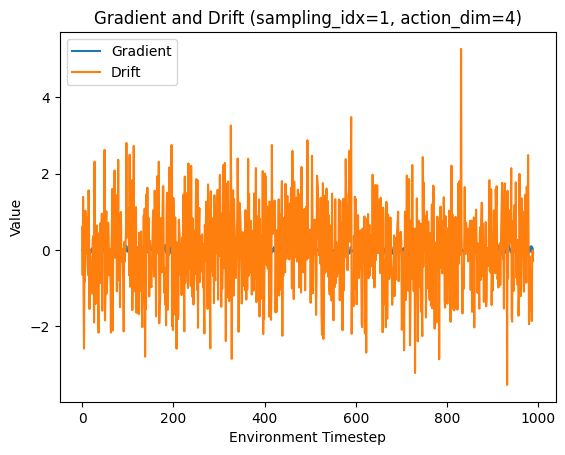

In [151]:
# Plot gradient and drift along the specified sampling_idx and action_dim

sampling_idx = 1  # This selects which sampling_timestep you want to plot
action_dim = 4    # This selects which action dimension you want to plot

gradient_trace = extracted_guidance_vals[:, sampling_idx, action_dim]
drift_trace = extracted_drift_vals[:, sampling_idx, action_dim]

plt.plot(gradient_trace, label='Gradient')
plt.plot(drift_trace, label='Drift')
plt.title(f"Gradient and Drift (sampling_idx={sampling_idx}, action_dim={action_dim})")
plt.xlabel("Environment Timestep")
plt.ylabel("Value")
plt.legend()
plt.show()

t: 9, clean_pred_q: -50.886619567871094, ref_q: -51.56877136230469
t: 8, clean_pred_q: -51.28556442260742, ref_q: -51.56877136230469
t: 7, clean_pred_q: -51.58281326293945, ref_q: -51.56877136230469
t: 6, clean_pred_q: -51.38376235961914, ref_q: -51.56877136230469
t: 5, clean_pred_q: -51.510860443115234, ref_q: -51.56877136230469
t: 4, clean_pred_q: -50.76094055175781, ref_q: -51.56877136230469
t: 3, clean_pred_q: -50.902374267578125, ref_q: -51.56877136230469
t: 2, clean_pred_q: -51.02479934692383, ref_q: -51.56877136230469
t: 1, clean_pred_q: -51.01695251464844, ref_q: -51.56877136230469
t: 0, clean_pred_q: -51.468021392822266, ref_q: -51.56877136230469
[ 0.98416996 -0.7373223   0.58716124 -0.6901325  -0.65508854 -0.7874202
 -0.882239    0.33166742]
--------------------------------
[ 0.8901222  -0.8013126   0.8298292  -0.45708293 -0.09746617 -0.62344307
 -0.978853    0.7986443 ] -50.817673


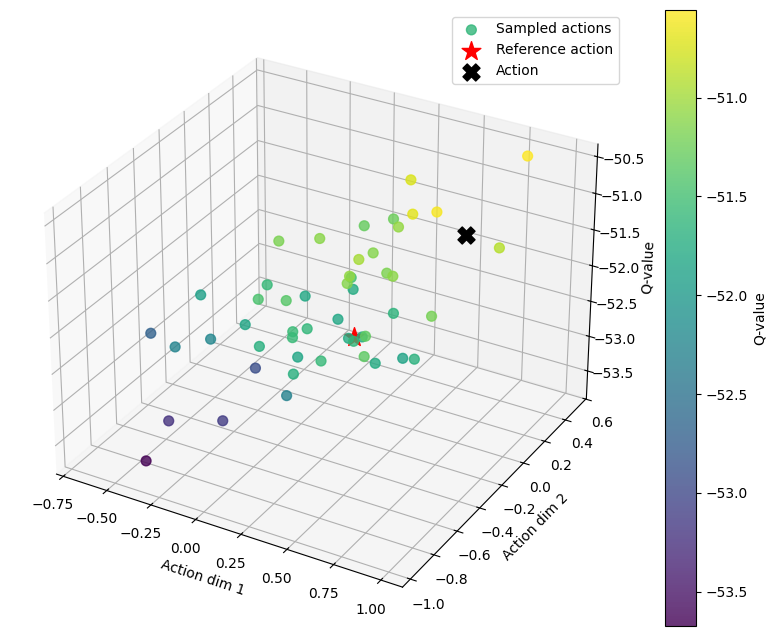

In [ ]:
t = 850

np_actions_list = np.array(actions_list[task_idx])
np_clean_preds_by_episode = np.array(clean_preds_by_episode[task_idx])
np_gradient_vals_by_episode = np.array(gradient_vals_by_episode[task_idx])
np_vels_by_episode = np.array(drifts_by_episode[task_idx])

np_observations = np.array(trajs[task_idx]['observation'])
np_actions = np.array(trajs[task_idx]['action'])

def get_ref_action(agent, observation, init_noise, diffusion_steps, rng):
    ref_action = init_noise

    noisy_qs = []

    for i in range(diffusion_steps):
        t = jnp.full((*observation.shape[:-1], 1), i / diffusion_steps)
        t_int = jnp.full((*observation.shape[:-1], 1), i)

        betas = agent.extract(agent.betas, t_int, ref_action.shape)
        sqrt_alphas = agent.extract(agent.sqrt_alphas, t_int, ref_action.shape)
        sqrt_one_minus_alphas_cumprod = agent.extract(agent.sqrt_one_minus_alphas_cumprod, t_int, ref_action.shape)
        pred = agent.network.select('actor_diffusion')(observation, ref_action, t)

        rng, step_noise_seed = jax.random.split(rng)

        step_noise = jax.random.normal(
            step_noise_seed,
            (
                *observation.shape[:-len(agent.config['ob_dims'])],
                ref_action.shape[-1]
            )
        )

        noise_scale = jnp.where(i > 0, jnp.sqrt(betas), 0)
        ref_action = ref_action / sqrt_alphas - betas / (sqrt_alphas * sqrt_one_minus_alphas_cumprod) * pred + noise_scale * step_noise

        noisy_q = agent.network.select('critic')(observation, ref_action).mean(axis=0)
        noisy_qs.append(noisy_q)

    ref_action = jnp.clip(ref_action, -1, 1)
    
    return ref_action

def compare_clean_pred(agent, observation, target_action, clean_preds):
    ref_q = agent.network.select('critic')(observation, target_action).mean(axis=0)
    for i in range(clean_preds.shape[0])[::-1]:
        clean_pred = clean_preds[i,...]
        clean_pred_q = agent.network.select('critic')(observation, clean_pred).mean(axis=0)
        print(f"t: {i}, clean_pred_q: {clean_pred_q}, ref_q: {ref_q}")


ref_action = dql_agent.sample_actions(np_observations[t,...].reshape(1,-1), seed=jax.random.PRNGKey(int(dql_seed)))[0]
ref_q = dql_agent.network.select('critic')(np_observations[t,...], ref_action).mean(axis=0)


# Compare clean prediction with true reference action (Quantitatively see the approximation error of one-step clean prediction)
compare_clean_pred(dql_agent, np_observations[t,...], ref_action, np_clean_preds_by_episode[t,...])
action_q = dql_agent.network.select('critic')(np_observations[t,...], np_actions[t,...]).mean(axis=0)


print(ref_action)

print("--------------------------------")

print(np_actions[t,...], action_q)


# Sample "num_samples" number of actions from the reference action distribution
num_samples = 50
n_observations = np_observations[t,...].reshape(1,-1).repeat(num_samples, axis=0)
ref_sampled_actions = dql_agent.sample_actions(n_observations, seed=jax.random.PRNGKey(int(dql_seed)))
ref_sampled_qs = dql_agent.network.select('critic')(n_observations, ref_sampled_actions).mean(axis=0)


# 3D Scatter plot of reference action, action, and extra sampled actions
# Values you have to plot are ref_action (ref_q), np_actions[t,...] (action_q), ref_sampled_actions (ref_sampled_qs)
fig = plt.figure(figsize=(10, 8), dpi=100)
ax = fig.add_subplot(111, projection='3d')

# With ref_sampled_qs, find the top 2 most correlated action dims with q
correlations = []
for dim in range(ref_sampled_actions.shape[1]):
    corr = np.corrcoef(ref_sampled_actions[:, dim], ref_sampled_qs)[0, 1]
    correlations.append(corr)
correlations = np.array(correlations)
action_dim1, action_dim2 = np.argsort(correlations)[-2:][::-1]


# Plot sampled actions
ax.scatter(
    ref_sampled_actions[:, action_dim1],
    ref_sampled_actions[:, action_dim2],
    ref_sampled_qs,
    c=ref_sampled_qs,
    cmap='viridis',
    s=50,
    alpha=0.8,
    label='Sampled actions'
)

# Plot reference action
ax.scatter(
    ref_action[action_dim1],
    ref_action[action_dim2],
    ref_q,
    color='red',
    marker='*',
    s=200,
    label='Reference action'
)

# Plot action
ax.scatter(
    np_actions[t, action_dim1],
    np_actions[t, action_dim2],
    action_q,
    color='black',
    marker='X',
    s=150,
    label='Action'
)

ax.set_xlabel('Action dim 1')
ax.set_ylabel('Action dim 2')
ax.set_zlabel('Q-value')
plt.colorbar(ax.collections[0], ax=ax, label='Q-value')
plt.legend()
plt.show()


t: 0, clean_pred_q: -51.468021392822266, ref_q: -51.56877136230469
t: 1, clean_pred_q: -51.01695251464844, ref_q: -51.56877136230469
t: 2, clean_pred_q: -51.02479934692383, ref_q: -51.56877136230469
t: 3, clean_pred_q: -50.902374267578125, ref_q: -51.56877136230469
t: 4, clean_pred_q: -50.76094055175781, ref_q: -51.56877136230469
t: 5, clean_pred_q: -51.510860443115234, ref_q: -51.56877136230469
t: 6, clean_pred_q: -51.38376235961914, ref_q: -51.56877136230469
t: 7, clean_pred_q: -51.58281326293945, ref_q: -51.56877136230469
t: 8, clean_pred_q: -51.28556442260742, ref_q: -51.56877136230469
t: 9, clean_pred_q: -50.886619567871094, ref_q: -51.56877136230469
[ 0.98416996 -0.7373223   0.58716124 -0.6901325  -0.65508854 -0.7874202
 -0.882239    0.33166742]
--------------------------------
[ 0.8901222  -0.8013126   0.8298292  -0.45708293 -0.09746617 -0.62344307
 -0.978853    0.7986443 ] -50.817673


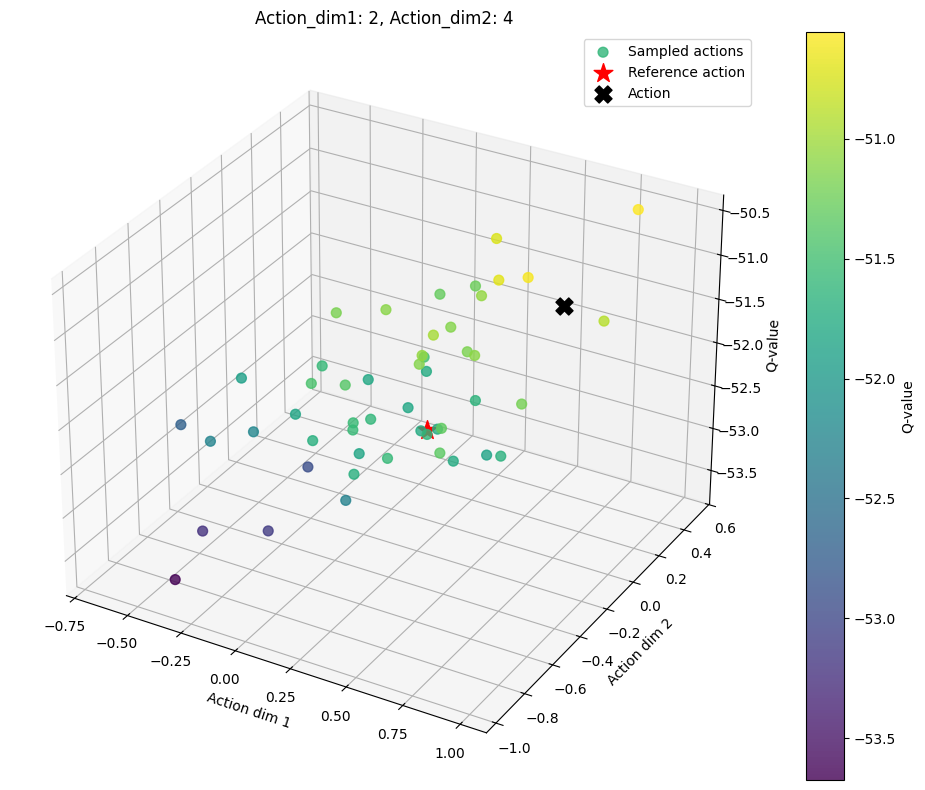

Time step: 4
[0.5399519]


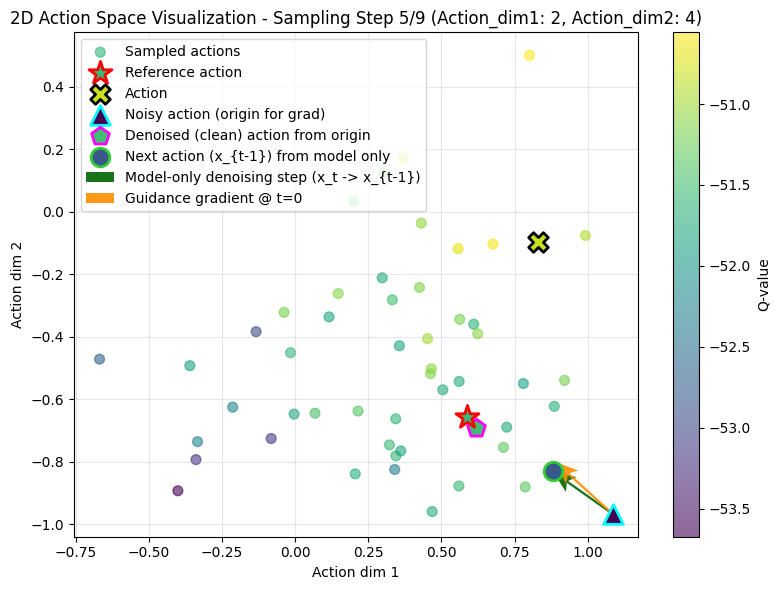

Time step: 3
[0.4768712]


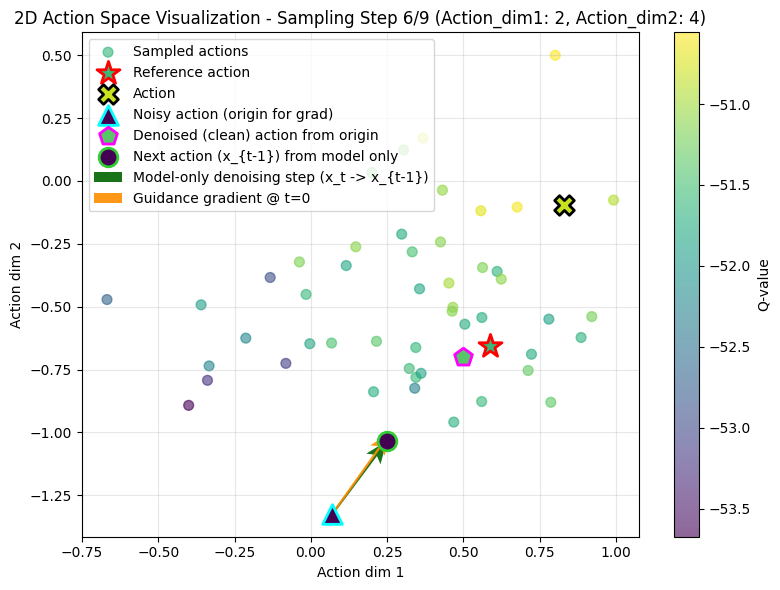

Time step: 2
[0.4197455]


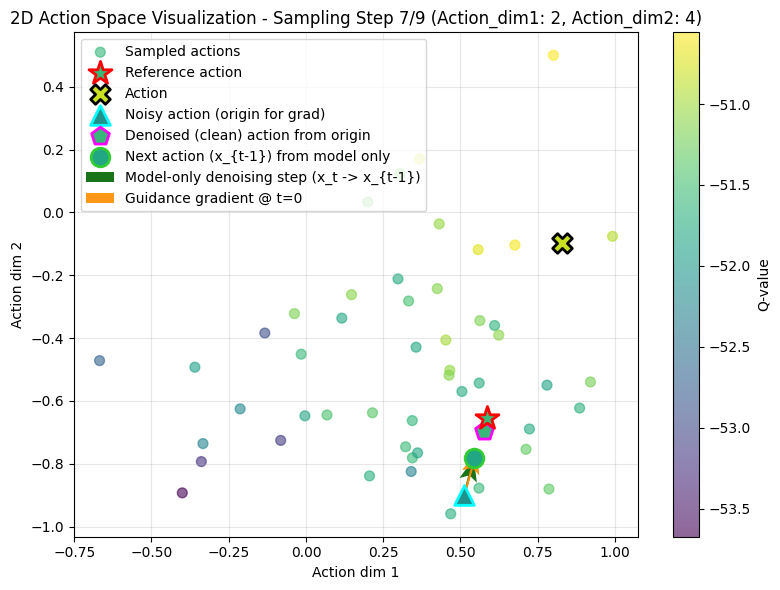

Time step: 1
[0.35850465]


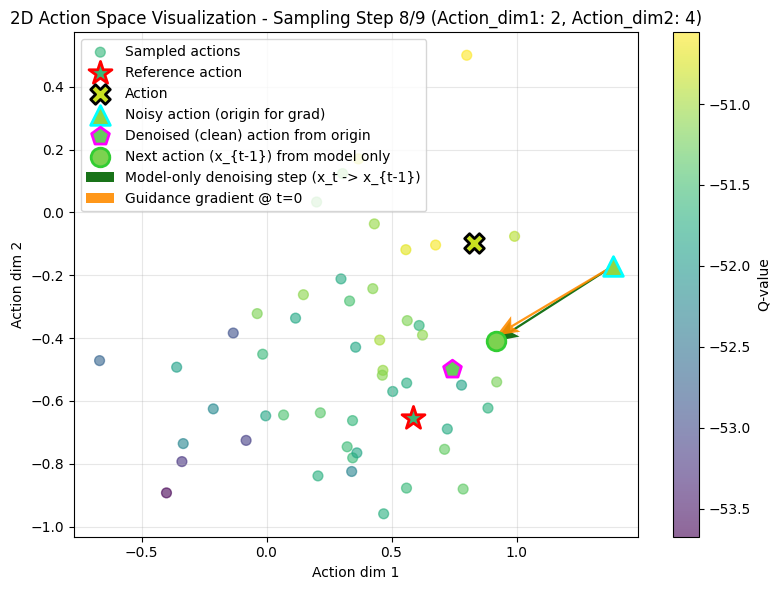

Time step: 0
[0.24759987]


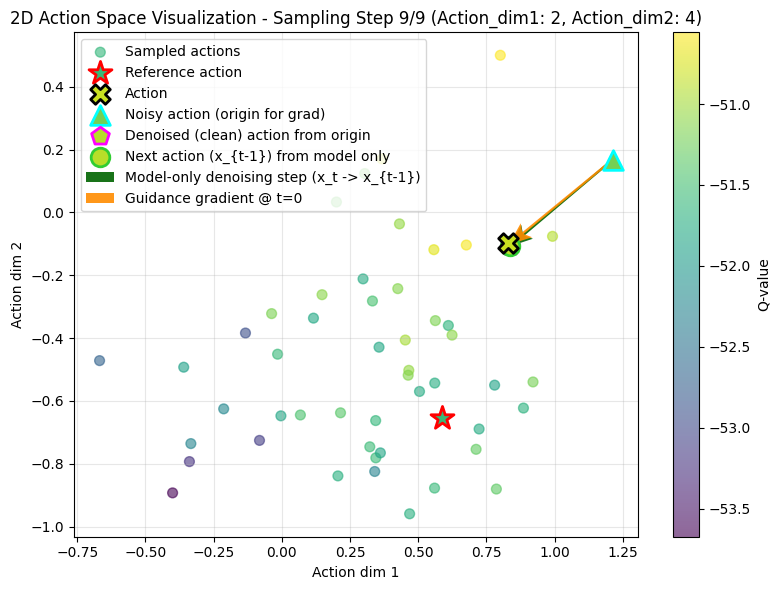

In [160]:
t = 850

np_actions_list = np.array(actions_list[task_idx])
np_clean_preds_by_episode = np.array(clean_preds_by_episode[task_idx])
np_gradient_vals_by_episode = np.array(gradient_vals_by_episode[task_idx])
np_drifts_by_episode = np.array(drifts_by_episode[task_idx])  # shape: (episode_len, diffusion_steps, action_dim)

np_observations = np.array(trajs[task_idx]['observation'])
np_actions = np.array(trajs[task_idx]['action'])

def get_ref_action(agent, observation, init_noise, diffusion_steps, rng):
    ref_action = init_noise

    noisy_qs = []

    for i in range(diffusion_steps):
        t = jnp.full((*observation.shape[:-1], 1), i / diffusion_steps)
        t_int = jnp.full((*observation.shape[:-1], 1), i)

        betas = agent.extract(agent.betas, t_int, ref_action.shape)
        sqrt_alphas = agent.extract(agent.sqrt_alphas, t_int, ref_action.shape)
        sqrt_one_minus_alphas_cumprod = agent.extract(agent.sqrt_one_minus_alphas_cumprod, t_int, ref_action.shape)
        pred = agent.network.select('actor_diffusion')(observation, ref_action, t)

        rng, step_noise_seed = jax.random.split(rng)

        step_noise = jax.random.normal(
            step_noise_seed,
            (
                *observation.shape[:-len(agent.config['ob_dims'])],
                ref_action.shape[-1]
            )
        )

        noise_scale = jnp.where(i > 0, jnp.sqrt(betas), 0)
        ref_action = ref_action / sqrt_alphas - betas / (sqrt_alphas * sqrt_one_minus_alphas_cumprod) * pred + noise_scale * step_noise

        noisy_q = agent.network.select('critic')(observation, ref_action).mean(axis=0)
        noisy_qs.append(noisy_q)

    ref_action = jnp.clip(ref_action, -1, 1)
    
    return ref_action

def compare_clean_pred(agent, observation, target_action, clean_preds):
    ref_q = agent.network.select('critic')(observation, target_action).mean(axis=0)
    for i in range(clean_preds.shape[0]):
        clean_pred = clean_preds[i,...]
        clean_pred_q = agent.network.select('critic')(observation, clean_pred).mean(axis=0)
        print(f"t: {i}, clean_pred_q: {clean_pred_q}, ref_q: {ref_q}")


ref_action = dql_agent.sample_actions(np_observations[t,...].reshape(1,-1), seed=jax.random.PRNGKey(int(dql_seed)))[0]
ref_q = dql_agent.network.select('critic')(np_observations[t,...], ref_action).mean(axis=0)

# Compare clean prediction with true reference action (Quantitatively see the approximation error of one-step clean prediction)
compare_clean_pred(dql_agent, np_observations[t,...], ref_action, np_clean_preds_by_episode[t,...])
action_q = dql_agent.network.select('critic')(np_observations[t,...], np_actions[t,...]).mean(axis=0)

print(ref_action)

print("--------------------------------")

print(np_actions[t,...], action_q)

# Sample "num_samples" number of actions from the reference action distribution
num_samples = 50
n_observations = np_observations[t,...].reshape(1,-1).repeat(num_samples, axis=0)
ref_sampled_actions = dql_agent.sample_actions(n_observations, seed=jax.random.PRNGKey(int(dql_seed)))
ref_sampled_qs = dql_agent.network.select('critic')(n_observations, ref_sampled_actions).mean(axis=0)

# 3D Scatter plot of reference action, action, and extra sampled actions
fig = plt.figure(figsize=(10, 8), dpi=100)
ax = fig.add_subplot(111, projection='3d')

# With ref_sampled_qs, find the top 2 most correlated action dims with q
correlations = []
for dim in range(ref_sampled_actions.shape[1]):
    corr = np.corrcoef(ref_sampled_actions[:, dim], ref_sampled_qs)[0, 1]
    correlations.append(corr)
correlations = np.array(correlations)
action_dim1, action_dim2 = np.argsort(correlations)[-2:][::-1]

# Plot sampled actions
ax.scatter(
    ref_sampled_actions[:, action_dim1],
    ref_sampled_actions[:, action_dim2],
    ref_sampled_qs,
    c=ref_sampled_qs,
    cmap='viridis',
    s=50,
    alpha=0.8,
    label='Sampled actions'
)

# Plot reference action
ax.scatter(
    ref_action[action_dim1],
    ref_action[action_dim2],
    ref_q,
    color='red',
    marker='*',
    s=200,
    label='Reference action'
)

# Plot action
ax.scatter(
    np_actions[t, action_dim1],
    np_actions[t, action_dim2],
    action_q,
    color='black',
    marker='X',
    s=150,
    label='Action'
)

# ----- Additional point for origin (used for gradient/clean pred) -----
# Evaluate and plot the Q-value at the original (noisy) point as well
# (use the "origin" itself before conversion to clean/denoised action)

ax.set_title(f'Action_dim1: {action_dim1}, Action_dim2: {action_dim2}')
ax.set_xlabel('Action dim 1')
ax.set_ylabel('Action dim 2')
ax.set_zlabel('Q-value')
plt.colorbar(ax.collections[0], ax=ax, label='Q-value')
plt.tight_layout()
plt.legend()
plt.show()

# Plot gradient arrow (loop over all sampling steps)
diffusion_steps = dql_agent.config['diffusion_steps']
for sampling_step in range(5,diffusion_steps):
    i = diffusion_steps - sampling_step - 1  # i is used for extracting betas/alphas
    print(f"Time step: {i}")

    # Get the action at this sampling timestep from actions_list
    arrow_origin = np_actions_list[t, sampling_step, :]  # shape: (action_dim,)
    observation = np_observations[t, ...].reshape(1, -1)  # shape: (1, obs_dim)

    # Extract betas, alphas for this sampling timestep (needed for clean prediction)
    t_float = jnp.full((*observation.shape[:-1], 1), i / dql_agent.config['diffusion_steps'])
    t_int = jnp.full((*observation.shape[:-1], 1), i)

    betas = dql_agent.extract(dql_agent.betas, t_int, arrow_origin.shape)
    sqrt_alphas = dql_agent.extract(dql_agent.sqrt_alphas, t_int, arrow_origin.shape)
    sqrt_alphas_cumprod = dql_agent.extract(dql_agent.sqrt_alphas_cumprod, t_int, arrow_origin.shape)
    sqrt_one_minus_alphas_cumprod = dql_agent.extract(dql_agent.sqrt_one_minus_alphas_cumprod, t_int, arrow_origin.shape)
    print(betas / (sqrt_alphas * sqrt_one_minus_alphas_cumprod))

    # Get the prediction (preds) at this sampling step for computing clean action
    arrow_origin_jax = jnp.array(arrow_origin.reshape(1, -1))  # shape: (1, action_dim)
    preds = dql_agent.network.select('actor_diffusion')(observation, arrow_origin_jax, t_float)

    # Define Q function: Compute Q at a_0 (clean action), but gradient w.r.t. a_t (noisy action)
    def q_fn_at_target(a_t):
        a_0 = (a_t - sqrt_one_minus_alphas_cumprod * preds) / sqrt_alphas_cumprod
        qs = dql_agent.network.select('critic')(observation, a_0)
        return jnp.mean(qs)

    # Compute guidance gradient: gradient of Q w.r.t. a_t (noisy action)
    guidance_grad = jax.grad(q_fn_at_target)(arrow_origin_jax)[0]  # shape: (action_dim,)

    # Normalize gradient to have norm 1

    grad_norm = jnp.linalg.norm(guidance_grad)
    guidance_grad = guidance_coeff * guidance_grad / (grad_norm + 1e-8)
    # guidance_grad = jnp.clip(guidance_grad, -1, 1)
    guidance_grad = np.array(guidance_grad)  # Convert to numpy for visualization

    # Compute clean action (a_0) from noisy action (a_t) at origin
    a_0_origin = (arrow_origin_jax - sqrt_one_minus_alphas_cumprod * preds) / sqrt_alphas_cumprod
    a_0_origin = jnp.clip(a_0_origin, -1, 1)
    a_0_origin_np = np.array(a_0_origin[0])  # shape: (action_dim,)

    # Compute Q-value at the origin (using clean action a_0)
    q_origin = dql_agent.network.select('critic')(observation, a_0_origin).mean(axis=0)


    model_pred = np_drifts_by_episode[t, sampling_step, :]  # (action_dim,)
    arrow_origin_jax_for_step = jnp.array(arrow_origin.reshape(1, -1))
    model_pred_jax = jnp.array(model_pred.reshape(1, -1))

    # Add normalized gradient to origin (noisy action) and compute Q at that point
    a_0_end = arrow_origin_jax / sqrt_alphas - betas / (sqrt_alphas * sqrt_one_minus_alphas_cumprod) * (model_pred_jax - guidance_grad)
    a_0_end = jnp.clip(a_0_end, -1, 1)
    a_0_end_np = np.array(a_0_end[0])  # shape: (action_dim,)

    # Compute Q-value at the end point (using clean action a_0)
    q_end = dql_agent.network.select('critic')(observation, a_0_end).mean(axis=0)

    # Compute the arrow direction in clean action space
    arrow_direction_clean = a_0_end_np - arrow_origin

    # Additional: plot the one-step denoising using only model prediction (conventional diffusion step)

    # Apply conventional diffusion denoising step: x_{t-1} = x_t / sqrt_alphas - betas / (sqrt_alphas * sqrt_one_minus_alphas_cumprod) * pred
    # Note: For visualization, we omit the noise term to show the deterministic directio

    # Compute next timestep action using only model prediction (no guidance, no noise)
    # This is the conventional diffusion sampling step: x_{t-1} from x_t
    next_action_unguided = arrow_origin_jax_for_step / sqrt_alphas - betas / (sqrt_alphas * sqrt_one_minus_alphas_cumprod) * model_pred_jax
    # next_action_unguided = jnp.clip(next_action_unguided, -1, 1)
    next_action_unguided_np = np.array(next_action_unguided[0])  # shape: (action_dim,)

    # Compute Q-value at the next denoised action
    q_next_action_unguided = dql_agent.network.select('critic')(observation, next_action_unguided).mean(axis=0)

    # Compute Q-value at noisy action used for gradient computation (for visualization)
    q_origin_noisy = dql_agent.network.select('critic')(observation, arrow_origin_jax).mean(axis=0)

    # -----------------------------------------------------------
    # 2D visualization with arrows and points colored by Q-values
    # -----------------------------------------------------------

    fig2d = plt.figure(figsize=(8, 6), dpi=100)
    ax2d = fig2d.add_subplot(111)

    # Collect all points and their Q-values for 2D plot
    # Sampled actions
    scatter_2d = ax2d.scatter(
        ref_sampled_actions[:, action_dim1],
        ref_sampled_actions[:, action_dim2],
        c=ref_sampled_qs,
        cmap='viridis',
        s=50,
        alpha=0.6,
        label='Sampled actions',
        zorder=1
    )

    # Reference action
    ax2d.scatter(
        ref_action[action_dim1],
        ref_action[action_dim2],
        c=[ref_q],
        cmap='viridis',
        marker='*',
        s=300,
        edgecolors='red',
        linewidths=2,
        label='Reference action',
        zorder=5,
        vmin=ref_sampled_qs.min(),
        vmax=ref_sampled_qs.max()
    )

    # Action
    ax2d.scatter(
        np_actions[t, action_dim1],
        np_actions[t, action_dim2],
        c=[action_q],
        cmap='viridis',
        marker='X',
        s=200,
        edgecolors='black',
        linewidths=2,
        label='Action',
        zorder=5,
        vmin=ref_sampled_qs.min(),
        vmax=ref_sampled_qs.max()
    )

    # Noisy action (origin for grad)
    ax2d.scatter(
        arrow_origin[action_dim1],
        arrow_origin[action_dim2],
        c=[q_origin_noisy],
        cmap='viridis',
        marker='^',
        s=200,
        edgecolors='cyan',
        linewidths=2,
        label='Noisy action (origin for grad)',
        zorder=4,
        vmin=ref_sampled_qs.min(),
        vmax=ref_sampled_qs.max()
    )

    # Denoised (clean) action from origin
    ax2d.scatter(
        a_0_origin_np[action_dim1],
        a_0_origin_np[action_dim2],
        c=[q_origin],
        cmap='viridis',
        marker='p',
        s=180,
        edgecolors='magenta',
        linewidths=2,
        label='Denoised (clean) action from origin',
        zorder=4,
        vmin=ref_sampled_qs.min(),
        vmax=ref_sampled_qs.max()
    )

    # Next action (x_{t-1}) from model only
    ax2d.scatter(
        next_action_unguided_np[action_dim1],
        next_action_unguided_np[action_dim2],
        c=[q_next_action_unguided],
        cmap='viridis',
        marker='o',
        s=180,
        edgecolors='limegreen',
        linewidths=2,
        label='Next action (x_{t-1}) from model only',
        zorder=4,
        vmin=ref_sampled_qs.min(),
        vmax=ref_sampled_qs.max()
    )

    # Compute arrow directions
    arrow_direction_unguided = next_action_unguided_np - arrow_origin

    # Plot arrows in 2D
    # Model-only denoising step arrow
    ax2d.quiver(
        arrow_origin[action_dim1], 
        arrow_origin[action_dim2],
        arrow_direction_unguided[action_dim1], 
        arrow_direction_unguided[action_dim2],
        color='darkgreen',
        width=0.004,
        scale=1,
        scale_units='xy',
        angles='xy',
        headwidth=8,
        headlength=10,
        headaxislength=8,
        alpha=0.9,
        zorder=3,
        label='Model-only denoising step (x_t -> x_{t-1})'
    )

    # Guidance gradient arrow
    ax2d.quiver(
        arrow_origin[action_dim1], 
        arrow_origin[action_dim2],
        arrow_direction_clean[action_dim1], 
        arrow_direction_clean[action_dim2],
        color='darkorange',
        width=0.004,
        scale=1,
        scale_units='xy',
        angles='xy',
        headwidth=8,
        headlength=10,
        headaxislength=8,
        alpha=0.9,
        zorder=3,
        label='Guidance gradient @ t=0'
    )

    ax2d.set_title(f'2D Action Space Visualization - Sampling Step {sampling_step}/{diffusion_steps-1} (Action_dim1: {action_dim1}, Action_dim2: {action_dim2})')
    ax2d.set_xlabel('Action dim 1')
    ax2d.set_ylabel('Action dim 2')
    ax2d.grid(True, alpha=0.3)
    plt.colorbar(scatter_2d, ax=ax2d, label='Q-value')
    plt.tight_layout()
    plt.legend()
    plt.show()

100%|██████████| 4/4 [00:08<00:00,  2.19s/it]


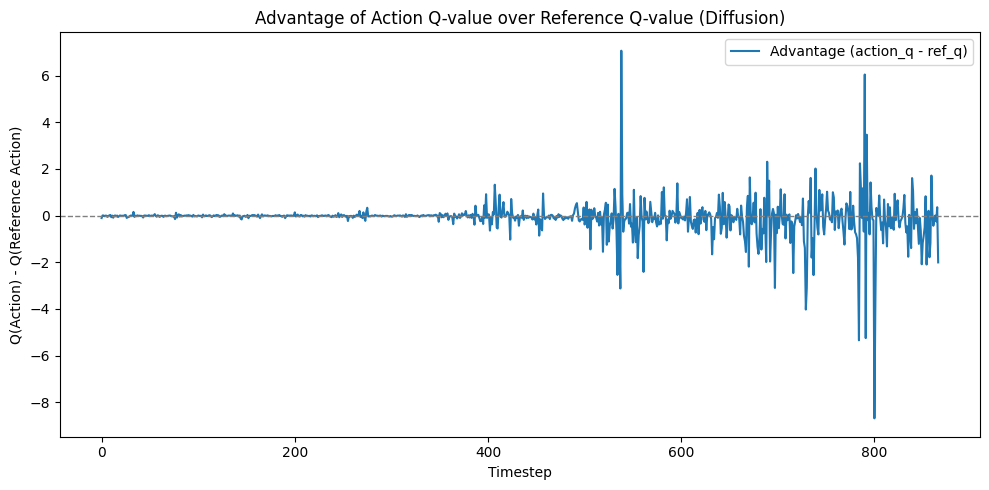

In [45]:
# Compare the reference action and actual action for all t steps, compatible with diffusion model (no ref_sampling)

np_actions_list = np.array(actions_list[task_idx])
np_clean_preds_by_episode = np.array(clean_preds_by_episode[task_idx])
np_gradient_vals_by_episode = np.array(gradient_vals_by_episode[task_idx])
np_vels_by_episode = np.array(drifts_by_episode[task_idx])

np_observations = np.array(trajs[task_idx]['observation'])
np_actions = np.array(trajs[task_idx]['action'])

# Diffusion-compatible get_ref_action
def get_ref_action(agent, observation, init_noise, diffusion_steps, rng):
    ref_action = init_noise
    for i in range(diffusion_steps):
        t = jnp.full((*observation.shape[:-1], 1), i / diffusion_steps)
        t_int = jnp.full((*observation.shape[:-1], 1), i)
        betas = agent.extract(agent.betas, t_int, ref_action.shape)
        sqrt_alphas = agent.extract(agent.sqrt_alphas, t_int, ref_action.shape)
        sqrt_one_minus_alphas_cumprod = agent.extract(agent.sqrt_one_minus_alphas_cumprod, t_int, ref_action.shape)
        pred = agent.network.select('actor_diffusion')(observation, ref_action, t)
        rng, step_noise_seed = jax.random.split(rng)
        step_noise = jax.random.normal(
            step_noise_seed,
            (*observation.shape[:-len(agent.config['ob_dims'])], ref_action.shape[-1])
        )
        noise_scale = jnp.where(i > 0, jnp.sqrt(betas), 0)
        ref_action = ref_action / sqrt_alphas - betas / (sqrt_alphas * sqrt_one_minus_alphas_cumprod) * pred + noise_scale * step_noise
    ref_action = jnp.clip(ref_action, -1, 1)
    return ref_action

def compare_clean_pred(agent, observation, target_action, clean_preds):
    ref_q = agent.network.select('critic')(observation, target_action).mean(axis=0)
    for i in range(clean_preds.shape[0]):
        clean_pred = clean_preds[i,...]
        clean_pred_q = agent.network.select('critic')(observation, clean_pred).mean(axis=0)
        print(f"t: {i}, clean_pred_q: {clean_pred_q}, ref_q: {ref_q}")

# We'll compare for all timesteps t in the episode

num_steps = np_observations.shape[0]
action_dim = np_actions.shape[1]

ref_actions = []
ref_qs = []
action_qs = []
batch_size = 256

num_batches = int(np.ceil(num_steps / batch_size))

diffusion_steps = np_clean_preds_by_episode.shape[1] if np_clean_preds_by_episode.ndim == 3 else np_clean_preds_by_episode.shape[0]

for batch_idx in tqdm(range(num_batches)):
    start = batch_idx * batch_size
    end = min((batch_idx + 1) * batch_size, num_steps)

    batch_observations = np_observations[start:end]
    batch_actions_0 = np_actions_list[start:end, 0, ...]
    batch_actions = np_actions[start:end]

    batch_ref_actions = []
    # Use a different random seed for each batch for reproducibility
    batch_rng = jax.random.PRNGKey(1234 + batch_idx)
    # Generate split rngs for each sample in batch
    batch_rngs = jax.random.split(batch_rng, end - start)

    for i in range(end - start):
        ref_action = dql_agent.sample_actions(
            batch_observations[i],
            batch_rngs[i]
        )
        batch_ref_actions.append(np.array(ref_action))
    batch_ref_actions = np.stack(batch_ref_actions, axis=0)

    batch_ref_qs = dql_agent.network.select('critic')(batch_observations, batch_ref_actions).mean(axis=0)
    batch_action_qs = dql_agent.network.select('critic')(batch_observations, batch_actions).mean(axis=0)

    ref_actions.append(batch_ref_actions)
    ref_qs.append(np.array(batch_ref_qs))
    action_qs.append(np.array(batch_action_qs))

ref_actions = np.concatenate(ref_actions, axis=0)
ref_qs = np.concatenate(ref_qs, axis=0)
action_qs = np.concatenate(action_qs, axis=0)

# Plot the advantage of action q over ref_q across all timesteps
advantage_q = action_qs - ref_qs

plt.figure(figsize=(10, 5))
plt.plot(advantage_q, label='Advantage (action_q - ref_q)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Timestep')
plt.ylabel('Q(Action) - Q(Reference Action)')
plt.title('Advantage of Action Q-value over Reference Q-value (Diffusion)')
plt.legend()
plt.tight_layout()
plt.show()

# Optionally: print some statistics of difference
mae = np.mean(np.abs(ref_actions - np_actions), axis=0)

In [99]:
advantage_q.min(), advantage_q.mean(), advantage_q.max()

(-8.685228, -0.096878506, 7.0659714)

## IFQL Analysis

In [119]:
ifql_task_idx = 1
ifql_env_name = f"antmaze-large-navigate-singletask-task{ifql_task_idx}-v0"
ifql_env_name = f"humanoidmaze-medium-navigate-singletask-task{ifql_task_idx}-v0"
ifql_seed = 0
buffer_size = 2000000
eval_episodes = 10

# Initialize random seeds
random.seed(ifql_seed)
np.random.seed(ifql_seed)

# IFQL Training hyperparameters (from run_ifql_pipeline.sh)
ifql_expectile = 0.9
ifql_num_samples = 32
ifql_flow_steps = 10
ifql_reward_discount = 0.995
ifql_use_value_layer_norm = True
ifql_use_actor_layer_norm = False
ifql_offline_steps = 1000000


env, eval_env, train_dataset, val_dataset = make_env_and_datasets(ifql_env_name, frame_stack=None)
train_dataset = Dataset.create(**train_dataset)
train_dataset = ReplayBuffer.create_from_initial_dataset(
    dict(train_dataset), size=max(buffer_size, train_dataset.size + 1)
)

example_batch = train_dataset.sample(1)

# Build IFQL experiment name and path (following run_ifql_pipeline.sh pattern)
ifql_exp_name = f"{ifql_env_name}_expectile{ifql_expectile}-numsamples{ifql_num_samples}-flow{ifql_flow_steps}-discount{ifql_reward_discount}_sd{ifql_seed:03d}"


print(ifql_exp_name)

ifql_base_dir = "exp"
ifql_run_group = ifql_env_name
ifql_agent_path = f"{ifql_base_dir}/ifql/{ifql_run_group}/{ifql_exp_name}"
ifql_restore_epoch = ifql_offline_steps

# Load IFQL agent config (following guidance_evaluation.py pattern)
import importlib.util
ifql_agent_config_path = "agents/ifql.py"
ifql_spec = importlib.util.spec_from_file_location("ifql_agent_config", ifql_agent_config_path)
ifql_agent_config_module = importlib.util.module_from_spec(ifql_spec)
ifql_spec.loader.exec_module(ifql_agent_config_module)
ifql_config = ifql_agent_config_module.get_config()

# Set IFQL hyperparameters in config (following run_ifql_pipeline.sh pattern)
ifql_config.expectile = ifql_expectile
ifql_config.num_samples = ifql_num_samples
ifql_config.flow_steps = ifql_flow_steps
ifql_config.discount = ifql_reward_discount
ifql_config.layer_norm = ifql_use_value_layer_norm
ifql_config.actor_layer_norm = ifql_use_actor_layer_norm

# Create IFQL agent (following guidance_evaluation.py pattern)
ifql_agent_class = agents[ifql_config['agent_name']]
ifql_agent = ifql_agent_class.create(
    ifql_seed,
    example_batch['observations'],
    example_batch['actions'],
    ifql_config,
)

# Restore IFQL agent (following guidance_evaluation.py pattern)
if ifql_agent_path and ifql_restore_epoch:
    ifql_agent = restore_agent(ifql_agent, ifql_agent_path, ifql_restore_epoch)
    print(f"IFQL agent restored from {ifql_agent_path} at epoch {ifql_restore_epoch}")

print("IFQL model loaded successfully!")


humanoidmaze-medium-navigate-singletask-task1-v0_expectile0.9-numsamples32-flow10-discount0.995_sd000
Restored from exp/ifql/humanoidmaze-medium-navigate-singletask-task1-v0/humanoidmaze-medium-navigate-singletask-task1-v0_expectile0.9-numsamples32-flow10-discount0.995_sd000/params_1000000.pkl
IFQL agent restored from exp/ifql/humanoidmaze-medium-navigate-singletask-task1-v0/humanoidmaze-medium-navigate-singletask-task1-v0_expectile0.9-numsamples32-flow10-discount0.995_sd000 at epoch 1000000
IFQL model loaded successfully!


In [5]:
import jax.numpy as jnp
from tqdm import trange


def sample_action_with_guidance(
        agent,
        observations,
        energy_fn,
        seed=None,
        guidance_coeff=1.0,
        temperature=1.0,
        partial_guidance=-1,
    ):
    """
    Sample actions from the policy with energy-based guidance.
    
    Args:
        observations: Current observations
        energy_fn: Energy function that takes (observations, actions) and returns energy values
        seed: Random seed for sampling
        guidance_coeff: Guidance strength coefficient
        temperature: Sampling temperature
        partial_guidance: If -1, apply guidance for entire sampling process.
                        If > 0 and < flow_steps, apply guidance only to last {partial_guidance} steps.
        
    Returns:
        actions: Sampled actions with guidance applied
        energy_vals: List of energy values computed during sampling
        gradient_vals: List of gradient values computed during sampling
        cosine_sim_vals: List of cosine similarity values between Q-gradient and safety gradient
    """
    
    # In place condition for experiment purpose
    rescale_strategy = "normalize" # to be move to guidance_evaluation main function
    pred_clean = True
    guidance_scheduling = "fixed"
    last_step_guidance = True

    def get_guidance_strength(i, exp_k=5):
        """
        Treat the guidance_coeff as max strength
        """
        min_guidance = 0.0

        if guidance_scheduling == "fixed":
            return guidance_coeff
        elif guidance_scheduling == "neg_linear": # start from guidance_coeff and decrease linearly
            return guidance_coeff - (guidance_coeff - min_guidance) * (i+1) / flow_steps
        elif guidance_scheduling == "linear":
            return min_guidance + (guidance_coeff - min_guidance) * (i+1) / flow_steps
        elif guidance_scheduling == "exp":
            factor = (jnp.exp((i+1) * exp_k / flow_steps) - 1) / (jnp.exp(exp_k) - 1)
            return min_guidance + (guidance_coeff - min_guidance) * factor
        else:
            raise ValueError(f"Invalid guidance_scheduling: {guidance_scheduling}")

    # Original fixed guidance coefficient method
    vels_list = [] # model prediction for each step
    gradient_vals = []
    clean_preds = []
    actions_list = []
    action_seed, noise_seed = jax.random.split(seed)
    
    # Handle encoder if needed
    orig_observations = observations
    if agent.config['encoder'] is not None:
        observations = agent.network.select('actor_flow_encoder')(observations)

    num_samples = agent.config['num_samples']

    if guidance_coeff != 0.0 and partial_guidance != 0:
        num_samples = 1
    
    # Sample `num_samples` noises and propagate through flow with guidance
    actions = jax.random.normal(
        action_seed,
        (
            *observations.shape[:-1],
            num_samples,
            agent.config['action_dim'],
        ),
    )

    # Determine when to apply guidance (matching FBRAC logic)
    flow_steps = agent.config['flow_steps']
    if partial_guidance == -1:
        guidance_start_step = 0
        guidance_end_step = flow_steps
    elif 0 < partial_guidance < flow_steps:
        if last_step_guidance:
            guidance_start_step = flow_steps - partial_guidance
            guidance_end_step = flow_steps
        else:
            guidance_start_step = 0
            guidance_end_step = partial_guidance
    else:
        guidance_start_step = flow_steps
        guidance_end_step = flow_steps
        print(f"Warning: Invalid partial_guidance value {partial_guidance}. Using no guidance.")
    
    # Pre-compile the gradient function once for better performance (only if we'll use guidance)
    energy_grad_fn = None
    if guidance_start_step < flow_steps:
        try:
            energy_grad_fn = agent._get_energy_grad_fn(energy_fn)
        except Exception as e:
            print(f"Error pre-compiling gradient function: {e}")
            energy_grad_fn = None
            
    # Tile observations for multi-candidate approach
    n_observations = jnp.repeat(jnp.expand_dims(observations, 0), num_samples, axis=0)
    n_orig_observations = jnp.repeat(jnp.expand_dims(orig_observations, 0), num_samples, axis=0)
    vs = agent.network.select('value')(n_orig_observations).min(axis=0)

    # Apply DDPM steps with conditional guidance
    for i in range(flow_steps):
        t = jnp.full((*observations.shape[:-1], num_samples, 1), i / flow_steps)
        
        # Get flow velocity from actor
        vels = agent.network.select('actor_flow')(n_observations, actions, t, is_encoded=True)

        guidance_weight = get_guidance_strength(i)

        # Only compute guidance if guidance_coeff is not zero
        # Use JAX conditional operations for JIT compatibility
        def apply_guidance():
            if energy_grad_fn is not None:
                # Compute Q value at target_actions (a_0), but gradient w.r.t. a_t
                def q_fn_batched(actions_batch):
                    # actions_batch: (num_samples, action_dim)
                    if pred_clean:
                        a_1 = actions_batch + (1 - t) * vels
                    else:
                        a_1 = actions_batch
                    qs = agent.network.select('critic')(n_observations, a_1)  # (E, num_samples)
                    # Sum of min Q-values across samples (scalar)
                    return jnp.sum(jnp.min(qs, axis=0))
                
                q_grad = jax.grad(q_fn_batched)(actions)  # Gradient w.r.t. a_t
                guidance_grad = q_grad

                if rescale_strategy == "normalize":
                    guidance_grad = guidance_grad / jnp.linalg.norm(guidance_grad)
                
                return guidance_grad, 0.0
            else:
                return jnp.zeros_like(vels), 0.0
        
        def no_guidance():
            return jnp.zeros_like(vels), 0.0
        
        should_apply = (guidance_coeff != 0.0 and
                        i >= guidance_start_step and
                        i < guidance_end_step and
                        energy_grad_fn is not None)
        
        # Use JAX conditional to choose guidance or no guidance
        guidance_grad, _ = jax.lax.cond(
            should_apply,
            apply_guidance,
            no_guidance
        )

        guidance_grad = jnp.where(
            jnp.isnan(guidance_grad) | jnp.isinf(guidance_grad),
            0.0,
            guidance_grad
        )
        guidance_grad = jnp.clip(guidance_weight*guidance_grad, -1, 1)

        gradient_vals.append(guidance_grad)
        vels_list.append(vels) # model prediction for each step
        a_1 = actions + (1 - t) * vels
        a_1 = jnp.clip(a_1, -1, 1)
        clean_preds.append(a_1) # one-step clean action prediction
        actions_list.append(actions) # current action for each step
        guided_vels = vels + guidance_grad

        actions = actions + guided_vels / flow_steps

    actions = jnp.clip(actions, -1, 1)
    # Pick action with highest Q-value
    q = agent.network.select('critic')(n_orig_observations, actions=actions).min(axis=0)

    if guidance_coeff == 0.0 or partial_guidance == 0:
        # falls back to rejection sampling
        actions = actions[jnp.argmax(q)]
    else:
        action_expectile = 1.0
        q_sorted_indices = jnp.argsort(q)
        if action_expectile == 1.0:
            expectile_idx = q.shape[0] - 1
        else:
            expectile_idx = int(action_expectile * (q.shape[0] - 1))
        chosen_idx = q_sorted_indices[expectile_idx]
        actions = actions[chosen_idx]
    return actions, vels_list, gradient_vals, clean_preds, actions_list

In [6]:
def eval_guidance(
    agent,
    env,
    energy_fn,
    config=None,
    num_eval_episodes=50,
    eval_temperature=0,
    guidance_coeff=1.0,
    partial_guidance=-1,
    seed=0,
    key=None,
):
    """Evaluate the agent in the environment using guided sampling.

    Args:
        agent: Agent with sample_action_with_guidance method.
        env: Environment.
        energy_fn: Energy function for guidance.
        config: Configuration dictionary.
        num_eval_episodes: Number of episodes to evaluate the agent.
        eval_temperature: Action sampling temperature.
        guidance_coeff: Guidance strength coefficient.
        partial_guidance: If -1, apply guidance for entire sampling process.
                         If > 0 and < flow_steps, apply guidance only to last {partial_guidance} steps.

    Returns:
        A tuple containing the statistics, trajectories, energy values, gradient values, and lambda values.
    """
    from collections import defaultdict
    
    # Create guided actor function
    def guided_actor_fn(observations, seed=None, temperature=eval_temperature):
        # Use regular fixed coefficient guidance method
        return sample_action_with_guidance(
            agent=agent,
            observations=observations,
            energy_fn=energy_fn,
            seed=seed,
            guidance_coeff=guidance_coeff,
            temperature=temperature,
            partial_guidance=partial_guidance
        )

    print(f"JIT-compiling guided actor function for coeff={guidance_coeff}...")
    if key is None:
        key = jax.random.PRNGKey(int(seed))
    guided_actor_fn = jax.jit(guided_actor_fn)
    trajs = []
    stats = defaultdict(list)
    energy_vals_by_episode = []
    gradient_vals_by_episode = []
    lambda_vals_by_episode = []
    cosine_sim_vals_by_episode = []

    for i in trange(num_eval_episodes, desc=f"Evaluating coeff={guidance_coeff}"):
        key, ep_key = jax.random.split(key)
        traj = defaultdict(list)
        energy_vals_list = []
        gradient_vals_list = []
        lambda_vals_list = []
        cosine_sim_vals_list = []
        observation, info = env.reset(seed=i)
        done = False
        step = 0
        while not done:
            ep_key, action_key = jax.random.split(ep_key)
            result = guided_actor_fn(observations=observation, temperature=eval_temperature, seed=action_key)
            # Handle different return formats based on guidance method
            if isinstance(result, tuple) and len(result) == 5:
                # Covariance method returns (action, energy_vals, gradient_vals, lambda_vals, cosine_sim_vals)
                action, energy_vals, gradient_vals, lambda_vals, cosine_sim_vals = result
                energy_vals_list.append(energy_vals)
                gradient_vals_list.append(gradient_vals)
                lambda_vals_list.append(lambda_vals)
                cosine_sim_vals_list.append(cosine_sim_vals)
            elif isinstance(result, tuple) and len(result) == 4:
                # Regular method returns (action, energy_vals, gradient_vals, cosine_sim_vals)
                action, energy_vals, gradient_vals, cosine_sim_vals = result
                energy_vals_list.append(energy_vals)
                gradient_vals_list.append(gradient_vals)
                cosine_sim_vals_list.append(cosine_sim_vals)
                # Create dummy lambda values if not provided
                lambda_vals_list.append([0.0])
            elif isinstance(result, tuple) and len(result) == 3:
                # Legacy format: (action, energy_vals, gradient_vals)
                action, energy_vals, gradient_vals = result
                energy_vals_list.append(energy_vals)
                gradient_vals_list.append(gradient_vals)
                # Create dummy lambda and cosine similarity values if not provided
                lambda_vals_list.append([0.0])
                cosine_sim_vals_list.append([0.0])
            elif isinstance(result, tuple) and len(result) == 2:
                action, energy_vals = result
                energy_vals_list.append(energy_vals)
                # Create dummy gradient, lambda, and cosine similarity values if not provided
                gradient_vals_list.append([jnp.zeros_like(observation)])
                lambda_vals_list.append([0.0])
                cosine_sim_vals_list.append([0.0])
            else:
                action = result
                # Create dummy energy, gradient, lambda, and cosine similarity values if not provided
                energy_vals_list.append(jnp.zeros(1))
                gradient_vals_list.append([jnp.zeros_like(observation)])
                lambda_vals_list.append([0.0])
                cosine_sim_vals_list.append([0.0])
            
            action = np.array(action)
            action = np.clip(action, -1, 1)

            next_observation, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            step += 1

            transition = dict(
                observation=observation,
                next_observation=next_observation,
                action=action,
                reward=reward,
                done=done,
                info=info,
            )
            from utils.evaluation import add_to
            add_to(traj, transition)
            observation = next_observation
        energy_vals_by_episode.append(energy_vals_list)
        gradient_vals_by_episode.append(gradient_vals_list)
        lambda_vals_by_episode.append(lambda_vals_list)
        cosine_sim_vals_by_episode.append(cosine_sim_vals_list)
        add_to(stats, flatten(info))
        trajs.append(traj)

    # Convert gradient values to regular Python lists for consistency
    def convert_nested_episodes(episodes):
        if episodes and len(episodes) > 0:
            converted_episodes = []
            for episode_vals in episodes:
                episode_list = []
                for val in episode_vals:
                    if hasattr(val, 'tolist'):
                        episode_list.append(val.tolist())
                    elif isinstance(val, (list, tuple)):
                        episode_list.append(list(val))
                    else:
                        episode_list.append(float(val))
                converted_episodes.append(episode_list)
            return converted_episodes
        else:
            return []

    gradient_vals_by_episode = convert_nested_episodes(gradient_vals_by_episode)
    energy_vals_by_episode = convert_nested_episodes(energy_vals_by_episode)
    cosine_sim_vals_by_episode = convert_nested_episodes(cosine_sim_vals_by_episode)
    lambda_vals_by_episode = convert_nested_episodes(lambda_vals_by_episode)

    for k, v in stats.items():
        stats[k] = np.mean(v)

    return stats, trajs, energy_vals_by_episode, gradient_vals_by_episode, lambda_vals_by_episode, cosine_sim_vals_by_episode

In [ ]:
random.seed(ifql_seed)
np.random.seed(ifql_seed)
os.environ['PYTHONHASHSEED'] = str(ifql_seed)
master_key = jax.random.PRNGKey(int(ifql_seed))

guidance_coeff = 0.0
partial_guidance = 0

stats, trajs, vels_by_episode, gradient_vals_by_episode, clean_preds_by_episode, actions_list = eval_guidance(
    agent=ifql_agent,
    config=ifql_config,
    env=eval_env,
    energy_fn=energy_fn,
    num_eval_episodes=50,
    guidance_coeff=guidance_coeff,
    partial_guidance=partial_guidance,
    seed=ifql_seed,
    key=master_key,
)

stats

JIT-compiling guided actor function for coeff=1.0...


Evaluating coeff=1.0: 100%|██████████| 50/50 [03:22<00:00,  4.05s/it]


defaultdict(list,
            {'xy': 18.982764335352783,
             'prev_qpos': 1.2021568586999605,
             'prev_qvel': -0.16975072834618382,
             'qpos': 1.1997954815889478,
             'qvel': -0.02402770200845857,
             'success': 0.68,
             'total.timesteps': 37625.22,
             'episode.final_reward': -0.32,
             'episode.return': -1469.0,
             'episode.length': 1469.68,
             'episode.duration': 4.045900998115539})

In [121]:
success_idx, failure_idx = get_success_failure_idx(trajs)

try:
    success_states = np.concatenate([np.array(x['observation']) for x in np.array(trajs)[success_idx]], axis=0)
    success_actions = np.concatenate([np.array(x['action']) for x in np.array(trajs)[success_idx]], axis=0)
except:
    success_states = np.concatenate([np.array(x['observation']) for x in np.array(trajs)[failure_idx]], axis=0)
    success_actions = np.concatenate([np.array(x['action']) for x in np.array(trajs)[failure_idx]], axis=0)
all_q_values = compute_q_values(ifql_agent, success_states, success_actions, batch_size=256)

num_states = 100 # number of states to evaluate
num_samples = 50 # number of ref model generations per state
ref_actions_list, ref_qs_list, target_actions_list, target_q_list, quantiles = compute_ref_target_q_values(
    ifql_agent, 
    success_states,
    success_actions,
    num_states=num_states,
    num_samples=num_samples,
    key=jax.random.PRNGKey(int(ifql_seed)),)

100%|██████████| 163/163 [00:14<00:00, 11.56it/s]


(41484,)


  0%|          | 0/100 [00:00<?, ?it/s]2025-11-01 22:08:54.102667: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-11-01 22:08:56.845534: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
100%|██████████| 100/100 [00:17<00:00,  5.83it/s]


Quantile Statistics:
Min: 0.25999999046325684, Mean: 0.8971999287605286, Median: 0.9799999594688416, Max: 1.0, Std: 0.16203753650188446


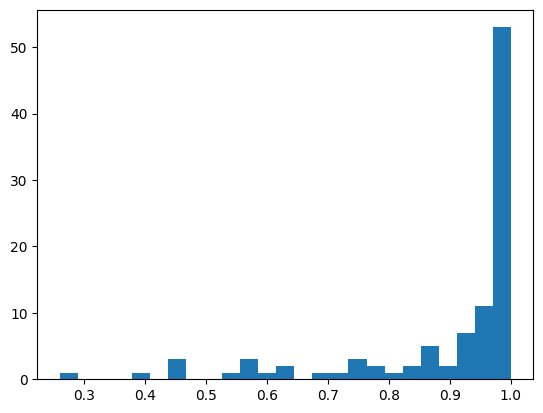

Number of top 5% quantile points: 100


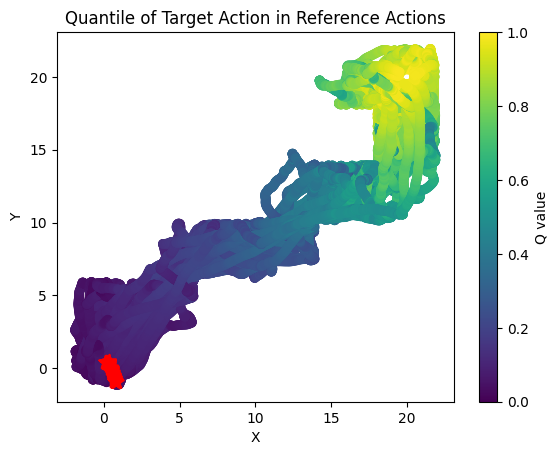

Top 2 most correlated action dims with q: [ 0 10], correlations: [ 0.60619044 -0.42350681]
-39.987934 -39.35205 -38.897858 0.23474401 1.0900764
[-38.90281]
Quantile of target_q in ref_qs: 0.980


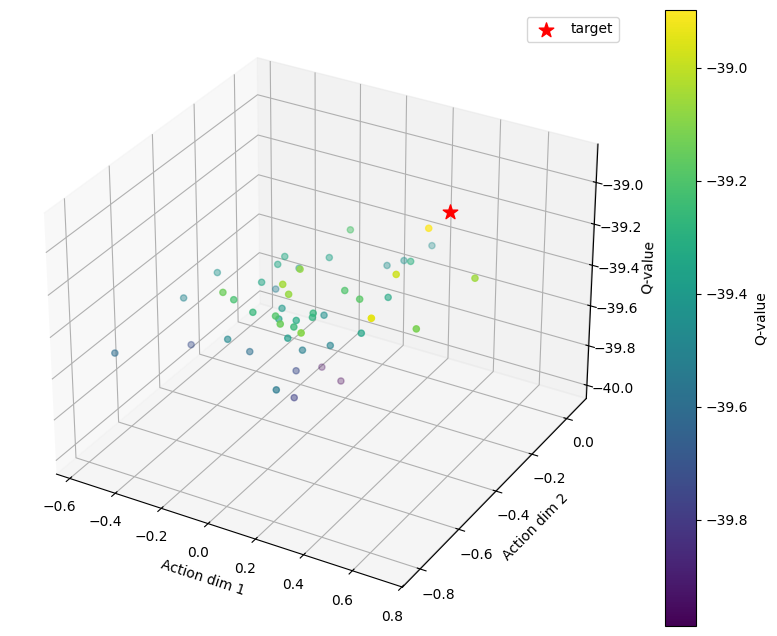

In [122]:
# ====== Quantile Histogram ======
# Plot the quantiles
print("Quantile Statistics:")
print(f"Min: {quantiles.min()}, Mean: {quantiles.mean()}, Median: {np.median(quantiles)}, Max: {quantiles.max()}, Std: {quantiles.std()}")
plt.hist(quantiles, bins=25)
plt.show()



# ====== Location Scatter Plot with Q-values ======
# Find the indices where the quantile is in the top 5%
top5_indices = np.where(quantiles > 0.2)[0]
print(f"Number of top 5% quantile points: {len(top5_indices)}")


top5_locations = success_states[top5_indices, :2]
all_locations = success_states[:, :2]

plt.scatter(all_locations[:, 0], all_locations[:, 1], c=all_q_values, cmap='viridis')
plt.scatter(top5_locations[:, 0], top5_locations[:, 1], c='red', marker='*', s=100)
plt.colorbar(label='Q value')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Quantile of Target Action in Reference Actions')
plt.show()


# ====== 3D Scatter Plot of Reference Actions and Q-values Along specified dimensions======
fig = plt.figure(figsize=(10, 8), dpi=100)
ax = fig.add_subplot(111, projection='3d')

# Select the target_idx based on the quantile value
lower_bound = 0.0
upper_bound = 1.0
selection_condition = (quantiles >= lower_bound) & (quantiles <= upper_bound)
target_idx = np.random.choice(np.where(selection_condition)[0])

ref_qs = ref_qs_list[target_idx]
ref_actions = ref_actions_list[target_idx]
target_action = target_actions_list[target_idx]
target_q = target_q_list[target_idx]

correlations = []
for dim in range(ref_actions.shape[1]):
    corr = np.corrcoef(ref_actions[:, dim], ref_qs)[0, 1]
    correlations.append(corr)
correlations = np.array(correlations)
abs_corr = np.abs(correlations)
top2_dims = abs_corr.argsort()[-2:][::-1]
print(f"Top 2 most correlated action dims with q: {top2_dims}, correlations: {correlations[top2_dims]}")

action_dim1, action_dim2 = top2_dims[0], top2_dims[1]
# action_dim1, action_dim2 = 0, 1

# Use first two action dimensions for the x and y axes, q-value for z and color.
sc = ax.scatter(
    ref_actions[:, action_dim1],                        # x-axis: action dim 1
    ref_actions[:, action_dim2],                        # y-axis: action dim 2
    ref_qs,                                             # z-axis: q-value
    c=ref_qs,                                           # color by q value
    cmap='viridis'
)

print(ref_qs.min(), ref_qs.mean(), ref_qs.max(), ref_qs.std(), ref_qs.max() - ref_qs.min())
print(target_q)

# Compute the quantile of target_q within ref_qs (i.e., its percentile location)
quantile = (ref_qs < target_q).mean()
print(f"Quantile of target_q in ref_qs: {quantile:.3f}")

# Plot the target action
ax.scatter(
    target_action[action_dim1], target_action[action_dim2], target_q,
    color='red', marker='*', s=120, label='target'
)

ax.set_xlabel('Action dim 1')
ax.set_ylabel('Action dim 2')
ax.set_zlabel('Q-value')
plt.colorbar(sc, ax=ax, label='Q-value')
plt.legend()
plt.show()

In [123]:
t = 850

np_actions_list = np.array(actions_list[task_idx])
np_clean_preds_by_episode = np.array(clean_preds_by_episode[task_idx])
np_gradient_vals_by_episode = np.array(gradient_vals_by_episode[task_idx])
np_vels_by_episode = np.array(vels_by_episode[task_idx])  # shape: (episode_len, flow_steps, action_dim)

np_observations = np.array(trajs[task_idx]['observation'])
np_actions = np.array(trajs[task_idx]['action'])

def get_ref_action(agent, observation, init_noise, flow_steps, rng):
    """IFQL flow matching: evolve noise through flow steps."""
    ref_action = init_noise
    
    # Handle encoder if needed
    orig_observation = observation
    if agent.config['encoder'] is not None:
        observation = agent.network.select('actor_flow_encoder')(observation)
    
    noisy_qs = []

    for i in range(flow_steps):
        t = jnp.full((*observation.shape[:-1], 1), i / flow_steps)
        
        # Get flow velocity from actor
        vels = agent.network.select('actor_flow')(observation, ref_action, t, is_encoded=(agent.config['encoder'] is not None))
        
        # Flow step: a_{i+1} = a_i + vels / flow_steps
        ref_action = ref_action + vels / flow_steps

        noisy_q = agent.network.select('critic')(orig_observation, ref_action).mean(axis=0)
        noisy_qs.append(noisy_q)

    ref_action = jnp.clip(ref_action, -1, 1)
    
    return ref_action

def compare_clean_pred(agent, observation, target_action, clean_preds):
    ref_q = agent.network.select('critic')(observation, target_action).mean(axis=0)
    for i in range(clean_preds.shape[0]):
        clean_pred = clean_preds[i,...]
        clean_pred_q = agent.network.select('critic')(observation, clean_pred).mean(axis=0)
        print(f"t: {i}, clean_pred_q: {clean_pred_q}, ref_q: {ref_q}")


### Gradient Analysis

In [124]:
# task_idx = np.random.choice(success_idx)
task_idx = 15

random.seed(ifql_seed)
np.random.seed(ifql_seed)

partial_guidance = 9

flow_steps = 10
gradient_vals = gradient_vals_by_episode[task_idx]
gradient_vals = np.array(gradient_vals)

vel_vals = vels_by_episode[task_idx]
vel_vals = np.array(vel_vals)

extracted_guidance_vals = []
extracted_vel_vals = []
for t in trange(len(gradient_vals)):
    sampling_traj = gradient_vals[t,-partial_guidance:]
    extracted_guidance_vals.append(sampling_traj)
    extracted_vel_vals.append(vel_vals[t,-partial_guidance:])

extracted_guidance_vals = np.array(extracted_guidance_vals)
extracted_vel_vals = np.array(extracted_vel_vals)
extracted_guidance_vals = extracted_guidance_vals.reshape(-1, partial_guidance, extracted_guidance_vals.shape[-1])
extracted_vel_vals = extracted_vel_vals.reshape(-1, partial_guidance, extracted_vel_vals.shape[-1])

extracted_guidance_vals.shape, extracted_vel_vals.shape

100%|██████████| 1378/1378 [00:00<00:00, 519574.88it/s]


((1378, 9, 21), (1378, 9, 21))

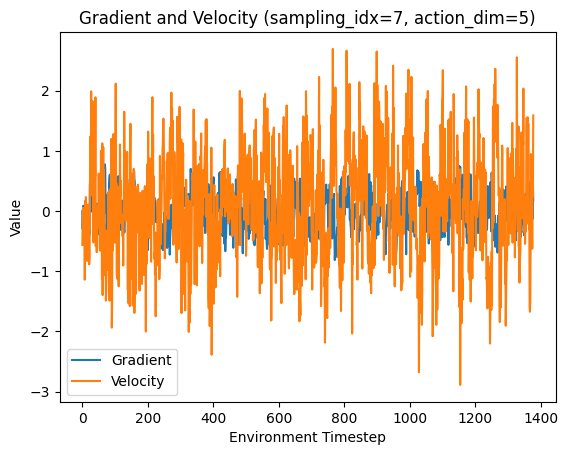

In [127]:
# Plot gradient and drift along the specified sampling_idx and action_dim

sampling_idx = 7  # This selects which sampling_timestep you want to plot
action_dim = 5    # This selects which action dimension you want to plot

gradient_trace = extracted_guidance_vals[:, sampling_idx, action_dim]
vel_trace = extracted_vel_vals[:, sampling_idx, action_dim]

plt.plot(gradient_trace, label='Gradient')
plt.plot(vel_trace, label='Velocity')
plt.title(f"Gradient and Velocity (sampling_idx={sampling_idx}, action_dim={action_dim})")
plt.xlabel("Environment Timestep")
plt.ylabel("Value")
plt.legend()
plt.show()

In [128]:
t = 200

np_actions_list = np.array(actions_list[task_idx])
np_clean_preds_by_episode = np.array(clean_preds_by_episode[task_idx])
np_gradient_vals_by_episode = np.array(gradient_vals_by_episode[task_idx])
np_vels_by_episode = np.array(vels_by_episode[task_idx])

np_observations = np.array(trajs[task_idx]['observation'])
np_actions = np.array(trajs[task_idx]['action'])

def get_ref_action(agent, observation, init_noise, flow_steps):
    ref_action = init_noise

    noisy_qs = []

    for i in range(flow_steps):
        t = jnp.full((*observation.shape[:-1], 1), i / flow_steps)
        vels = agent.network.select('actor_flow')(observation, ref_action, t, is_encoded=True)
        ref_action = ref_action + vels / flow_steps

        noisy_q = agent.network.select('critic')(observation, ref_action).mean(axis=0)
        noisy_qs.append(noisy_q)

    ref_action = jnp.clip(ref_action, -1, 1)
    
    return ref_action

def clean_action_prediction(agent, observation, action, t):
    vel = agent.network.select('actor_flow')(observation, action, t, is_encoded=True)
    a1 = action + (1 - t) * vel
    return a1

def compare_clean_pred(agent, observation, target_action, clean_preds):
    ref_q = agent.network.select('critic')(observation, target_action).mean(axis=0)
    for i in range(clean_preds.shape[0])[::-1]:
        clean_pred = clean_preds[i,...]
        clean_pred_q = agent.network.select('critic')(observation, clean_pred).mean(axis=0)
        print(f"t: {i}, clean_pred_q: {clean_pred_q}, ref_q: {ref_q}")

np_actions_list.shape

(1378, 10, 1, 21)

(256, 69)
(256,)


/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/matplotlib/cbook.py:1719: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return math.isfinite(val)
/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/matplotlib/cbook.py:1719: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return math.isfinite(val)
/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/matplotlib/cbook.py:1719: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return ma

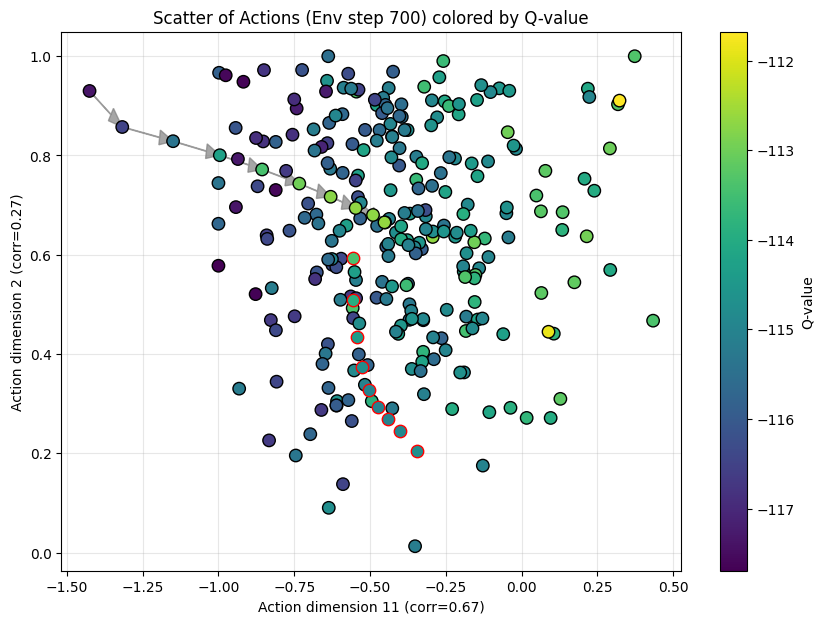

In [132]:
random.seed(ifql_seed)
np.random.seed(ifql_seed)

np_actions_list = np_actions_list.reshape(-1, flow_steps, np_actions_list.shape[-1])

env_step = 700

traj_actions = np_actions_list[env_step, ...]  # shape: (flow_steps, action_dim)
n_observations = np_observations[env_step].reshape(1, -1).repeat(traj_actions.shape[0], axis=0)

num_samples = 256

# Here, sample multiple reference actions and scatter plot them
ref_observations = np_observations[env_step].reshape(1, -1).repeat(num_samples, axis=0)
print(ref_observations.shape)
init_noise = jax.random.normal(jax.random.PRNGKey(np.random.randint(0, 1000000)), shape=(num_samples, np_actions_list.shape[-1]))
sampled_actions = get_ref_action(ifql_agent, ref_observations, init_noise, flow_steps)
# compute Q of them
sampled_qs = ifql_agent.network.select('critic')(ref_observations, sampled_actions).min(axis=0)
print(sampled_qs.shape)
# Compute Q value over traj_actions
traj_qs = ifql_agent.network.select('critic')(n_observations, traj_actions).min(axis=0)  # shape: (flow_steps,)

# Set the color range from mean - 5 to mean + 5
full_qs = np.concatenate([traj_qs, sampled_qs], axis=0)
qs_mean = np.mean(full_qs)
bound = 2
vmin = min(qs_mean-bound, full_qs.min())
vmax = max(qs_mean+bound, full_qs.max())

vmin = full_qs.min()
vmax = full_qs.max()

# Scatter plot the sampled actions over the two most correlated dims, colored by Q-values
plt.figure(figsize=(10, 7))
sc = plt.scatter(
    sampled_actions[:, action_dim1],
    sampled_actions[:, action_dim2],
    c=sampled_qs,
    cmap='viridis',
    s=80,
    edgecolors='k',
    zorder=3,
    vmin=vmin,
    vmax=vmax,
)


# Compute correlation between each action dimension and Q
pearson_corrs = []

full_actions = np.concatenate([traj_actions, sampled_actions], axis=0)
for i in range(full_actions.shape[1]):
    corr = np.corrcoef(full_actions[:, i], full_qs)[0, 1]
    pearson_corrs.append(corr)
pearson_corrs = np.array(pearson_corrs)
sorted_dim_indices = np.argsort(-np.abs(pearson_corrs))

action_dim1, action_dim2 = sorted_dim_indices[0], sorted_dim_indices[1]

# Scatterplot the traj_actions over the two most correlated dims, colored by Q-values with set color range
# plt.figure(figsize=(10, 7))
sc = plt.scatter(
    traj_actions[:, action_dim1],
    traj_actions[:, action_dim2],
    c=traj_qs,
    cmap='viridis',
    s=80,
    edgecolors='k',
    zorder=3,
    vmin=vmin,
    vmax=vmax,
)
plt.xlabel(f"Action dimension {action_dim1} (corr={pearson_corrs[action_dim1]:.2f})")
plt.ylabel(f"Action dimension {action_dim2} (corr={pearson_corrs[action_dim2]:.2f})")
plt.title(f"Scatter of Actions (Env step {env_step}) colored by Q-value")

traj_observation = np_observations[env_step].reshape(1, -1)

# Draw arrows from t to t+1 for each consecutive action
for t in range(traj_actions.shape[0] - 1):
    clean_pred = clean_action_prediction(ifql_agent, traj_observation, traj_actions[t:t+1], jnp.full((1,1), t/flow_steps))
    clean_pred_q = ifql_agent.network.select('critic')(traj_observation, clean_pred).min(axis=0)
    plt.scatter(
        clean_pred[0,action_dim1], clean_pred[0,action_dim2], 
        c=np.array([clean_pred_q]), cmap='viridis', s=80, edgecolors='red', zorder=3, 
        vmin=vmin, vmax=vmax
    )
    # plt.arrow(
    #     traj_actions[t, action_dim1], traj_actions[t, action_dim2],
    #     clean_pred[0,action_dim1] - traj_actions[t, action_dim1],
    #     clean_pred[0,action_dim2] - traj_actions[t, action_dim2],
    #     color="gray", alpha=0.7, head_width=0.03, length_includes_head=True, zorder=2
    # )

    x0, y0 = traj_actions[t, action_dim1], traj_actions[t, action_dim2]
    x1, y1 = traj_actions[t+1, action_dim1], traj_actions[t+1, action_dim2]
    plt.arrow(
        x0, y0, x1 - x0, y1 - y0,
        color="gray", alpha=0.7, head_width=0.03, length_includes_head=True, zorder=2
    )


cbar = plt.colorbar(sc)
cbar.set_label("Q-value")
plt.grid(True, alpha=0.3)
plt.show()


## IQL-family Analysis

In [85]:
def get_target_q_v_vals(target_coeff, target_task_idx):
    q_vals_by_coeff = load_json(q_vals_path)
    v_vals_by_coeff = load_json(v_vals_path)

    target_q_vals = q_vals_by_coeff[target_coeff]
    target_v_vals = v_vals_by_coeff[target_coeff]

    return np.array(target_q_vals[target_task_idx]), np.array(target_v_vals[target_task_idx])

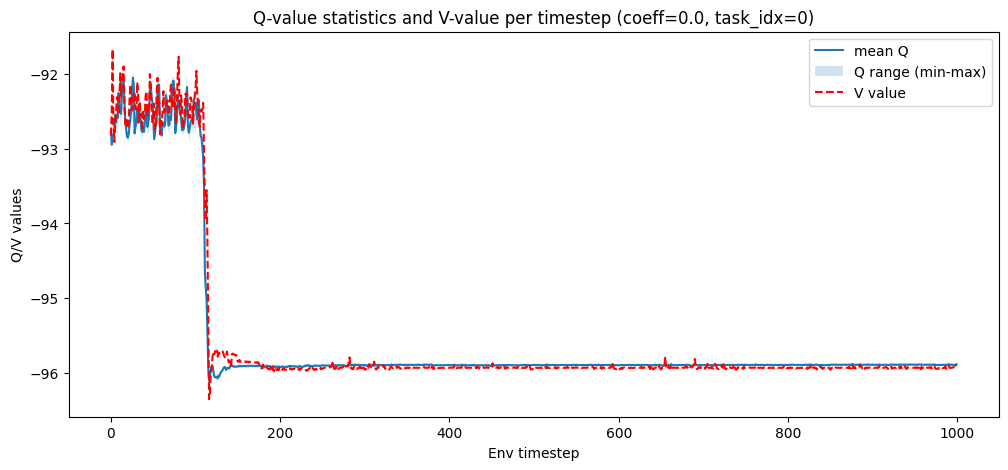

In [ ]:
target_task_idx = 0
target_coeff = "0.0"

np_target_q_vals, np_target_v_vals = get_target_q_v_vals(target_coeff, target_task_idx)

# Squeeze the 1-dim axis for easier plotting
q_vals_squeezed = np_target_q_vals.squeeze(1)  # shape: (env_timestep, num_samples)
v_vals_squeezed = np_target_v_vals.squeeze(1)  # shape: (env_timestep,)

timesteps = np.arange(len(q_vals_squeezed))

q_min = q_vals_squeezed.min(axis=-1)
q_mean = q_vals_squeezed.mean(axis=-1)
q_max = q_vals_squeezed.max(axis=-1)

plt.figure(figsize=(12, 5))
plt.plot(timesteps, q_mean, label="mean Q")
plt.fill_between(timesteps, q_min, q_max, alpha=0.2, label="Q range (min-max)")
plt.plot(timesteps, v_vals_squeezed, label="V value", linestyle="--", color="red")
plt.xlabel("Env timestep")
plt.ylabel("Q/V values")
plt.title("Q-value statistics and V-value per timestep (coeff={}, task_idx={})".format(target_coeff, target_task_idx))
plt.legend()
plt.show()

-2.3164443969726562 0.026911293029785156 5.577308654785156 0.43584780758007097


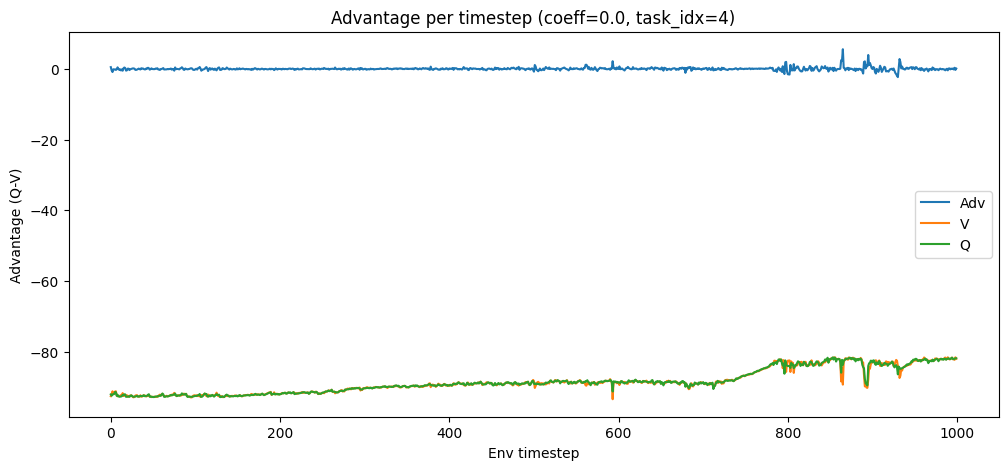

-4.554683685302734 0.3940564732096111 54.912110805511475 3.341397747292926


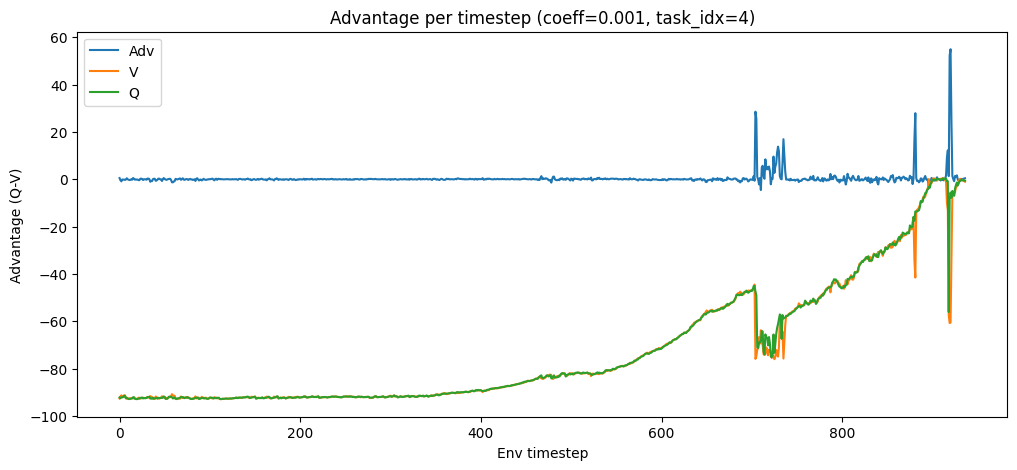

-26.030312538146973 0.259432541847229 26.87832260131836 2.3744252862411477


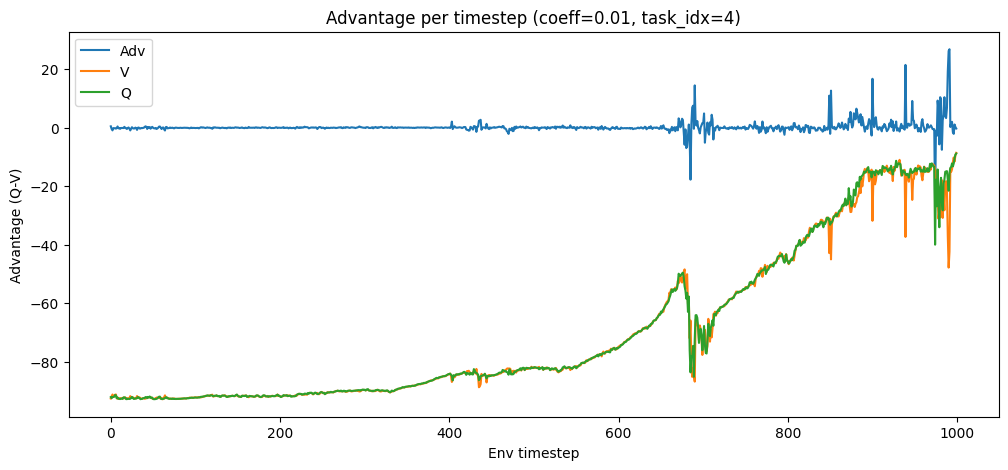

-12.654777526855469 0.2078012069761753 34.08543109893799 2.4443757296742317


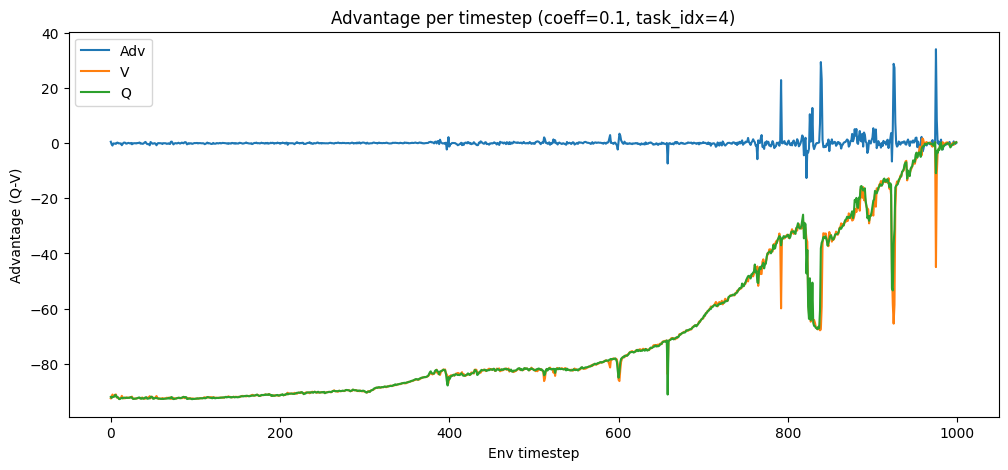

-3.554889678955078 0.18335086663052966 27.531368255615234 1.5938108858041677


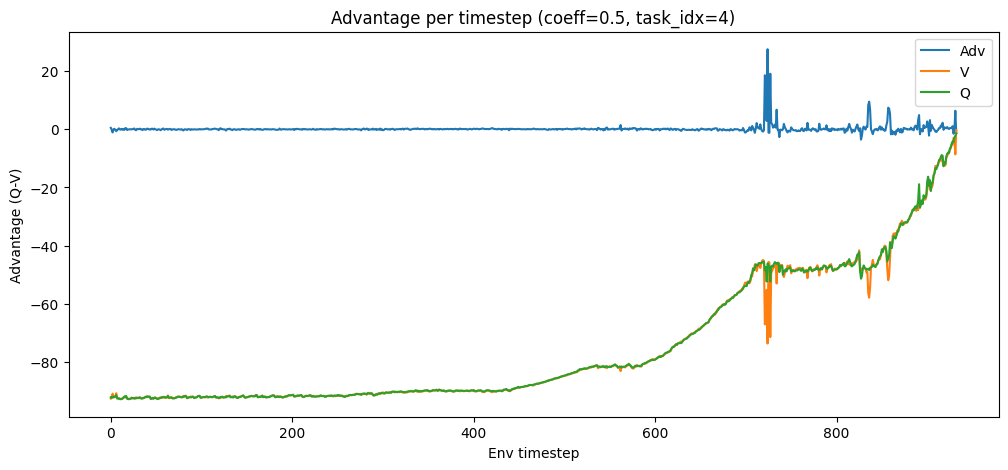

-1.3842315673828125 0.21220310974121093 0.747802734375 0.13272734333892225


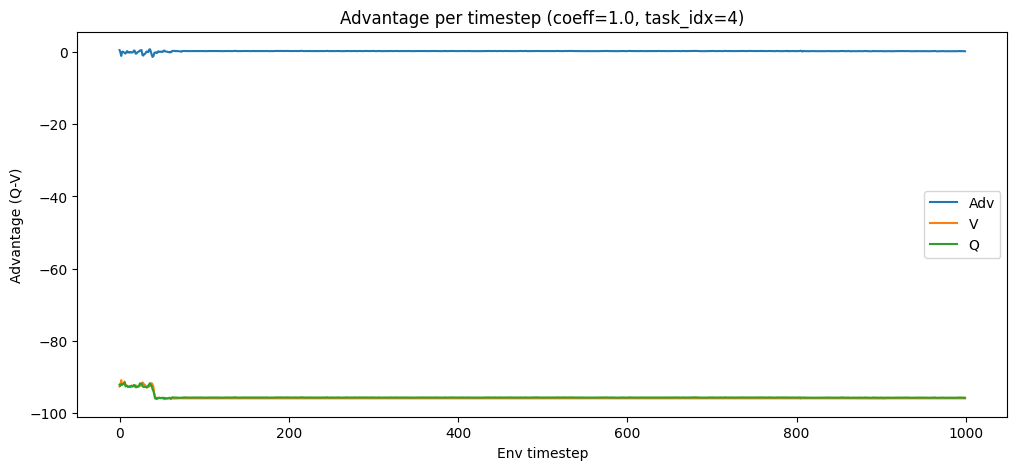

In [91]:
target_task_idx = 4
timestep_limit = -1
for target_coeff in ["0.0", "0.001", "0.01", "0.1", "0.5", "1.0"]:
    np_target_q_vals, np_target_v_vals = get_target_q_v_vals(target_coeff, target_task_idx)
    q_vals_squeezed = np_target_q_vals.squeeze(1)  # shape: (env_timestep, num_samples)
    v_vals_squeezed = np_target_v_vals.squeeze(1)  # shape: (env_timestep,)

    q_min = q_vals_squeezed.min(axis=-1)
    q_mean = q_vals_squeezed.mean(axis=-1)
    q_max = q_vals_squeezed.max(axis=-1)

    curr_t_limit = timestep_limit if timestep_limit != -1 else q_max.shape[0]
    curr_t_limit = np.min([curr_t_limit, q_max.shape[0]])

    adv = q_max - v_vals_squeezed
    print(adv[:curr_t_limit].min(), adv[:curr_t_limit].mean(), adv[:curr_t_limit].max(), adv[:curr_t_limit].std())

    plt.figure(figsize=(12, 5))
    plt.plot(timesteps[:curr_t_limit], adv[:curr_t_limit], label="Adv")
    plt.plot(timesteps[:curr_t_limit], v_vals_squeezed[:curr_t_limit], label="V")
    plt.plot(timesteps[:curr_t_limit], q_max[:curr_t_limit], label="Q")
    plt.xlabel("Env timestep")
    plt.ylabel("Advantage (Q-V)")
    plt.title("Advantage per timestep (coeff={}, task_idx={})".format(target_coeff, target_task_idx))
    plt.legend()
    plt.show()


## Energy, Gradient Visualization

In [13]:
def output_stats(target_np_array):
    return target_np_array.max(), target_np_array.min(), target_np_array.mean(), target_np_array.std()

target_coeff = "0.1"
target_task_idx=3

target_energy_vals = energy_vals_by_coeff[target_coeff]
target_gradient_vals = gradient_vals_by_coeff[target_coeff]
target_lambda_vals = lambda_vals_by_coeff[target_coeff]

energy_vals = np.array(target_energy_vals[target_task_idx]).reshape(len(target_energy_vals[target_task_idx]), -1)
gradient_vals = np.array(target_gradient_vals[target_task_idx])
lambda_vals = np.array(target_lambda_vals[target_task_idx]).reshape(len(target_lambda_vals[target_task_idx]))

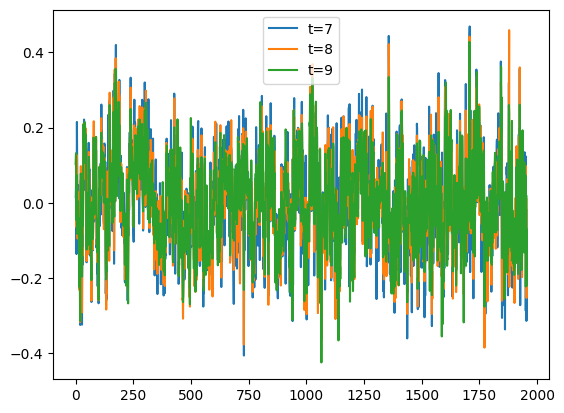

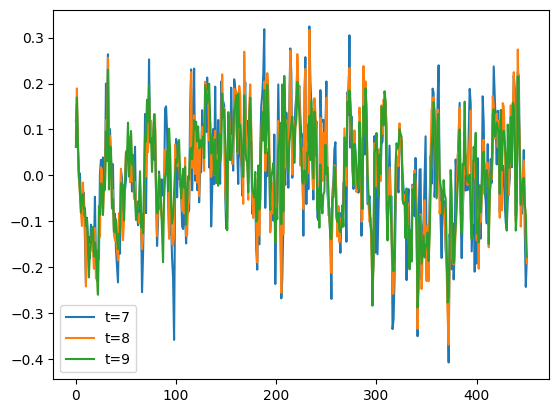

In [14]:
import matplotlib.pyplot as plt
target_task_idx=3

target_coeff = "0.1"
target_gradient_vals = gradient_vals_by_coeff[target_coeff]
gradient_vals = np.array(target_gradient_vals[target_task_idx])

for i in range(7, 10):
    # plot the mean of gradient over timesteps
    plt.plot(range(len(gradient_vals)), np.mean(gradient_vals[:,i,:], axis=-1), label=f"t={i}")
    plt.legend()

plt.show()

target_coeff = "0.5"
target_gradient_vals = gradient_vals_by_coeff[target_coeff]
gradient_vals = np.array(target_gradient_vals[target_task_idx])

for i in range(7, 10):
    # plot the mean of gradient over timesteps
    plt.plot(range(len(gradient_vals)), np.mean(gradient_vals[:,i,:], axis=-1), label=f"t={i}")
    plt.legend()


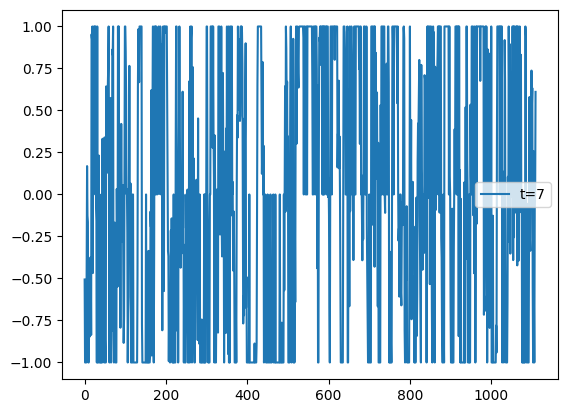

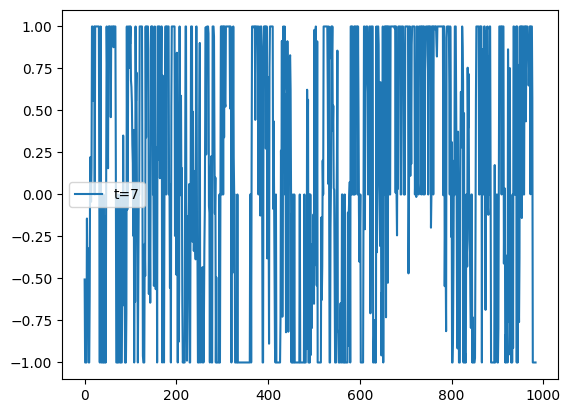

In [22]:
import matplotlib.pyplot as plt
target_task_idx=0
target_action_dim = 5

target_coeff = "0.01"
target_gradient_vals = gradient_vals_by_coeff[target_coeff]
gradient_vals = np.array(target_gradient_vals[target_task_idx])

start_step=7
end_step=8

for i in range(start_step, end_step):
    # plot the mean of gradient over timesteps
    plt.plot(range(len(gradient_vals)), gradient_vals[:,i,target_action_dim], label=f"t={i}")
    plt.legend()

plt.show()

target_coeff = "0.5"
target_gradient_vals = gradient_vals_by_coeff[target_coeff]
gradient_vals = np.array(target_gradient_vals[target_task_idx])

for i in range(start_step, end_step):
    # plot the mean of gradient over timesteps
    plt.plot(range(len(gradient_vals)), gradient_vals[:,i,target_action_dim], label=f"t={i}")
    plt.legend()


In [7]:
import matplotlib.pyplot as plt

target_coeff = "0.1"
target_task_idx=20

target_energy_vals = energy_vals_by_coeff[target_coeff]
target_gradient_vals = gradient_vals_by_coeff[target_coeff]

energy_vals = np.array(target_energy_vals[target_task_idx]).reshape(len(target_energy_vals[target_task_idx]), -1)
gradient_vals = np.array(target_gradient_vals[target_task_idx])

print(gradient_vals[200,7,:])

for i in range(7, 10):
    # plot the mean of gradient over timesteps
    plt.plot(range(len(gradient_vals)), np.mean(gradient_vals[:,i,:], axis=-1), label=f"t={i}")
    plt.legend()

plt.show()

target_coeff = "1.0"

target_energy_vals = energy_vals_by_coeff[target_coeff]
target_gradient_vals = gradient_vals_by_coeff[target_coeff]

energy_vals = np.array(target_energy_vals[target_task_idx]).reshape(len(target_energy_vals[target_task_idx]), -1)
gradient_vals = np.array(target_gradient_vals[target_task_idx])

for i in range(7, 10):
    # plot the mean of gradient over timesteps
    plt.plot(range(len(gradient_vals)), np.mean(gradient_vals[:,i,:], axis=-1), label=f"t={i}")
    plt.legend()


print(gradient_vals[500,7,:])

IndexError: list index out of range

In [18]:
target_timestep=4

temp = gradient_vals[target_timestep][-3,:]
temp_energy = energy_vals[target_timestep][-3]


print(f"Target Timestep: {target_timestep}")
print(f"Target Energy: {temp_energy}")
print(f"Target Gradient: {temp}")
print(f"Original Norm: {np.linalg.norm(temp)}")

print("Statistics:\n")
print(f"{output_stats(temp)}")

Target Timestep: 4
Target Energy: -6.662174224853516
Target Gradient: [-7.47993239e-04  2.92040035e-03 -3.09130806e-03 -1.12895633e-03
 -2.37996434e-03 -1.06749926e-02  6.89758162e-04  7.19760952e-04
  6.98754622e-04  1.57989771e-03  2.43380477e-04 -6.01172820e-03
 -8.01177230e-03  2.72798981e-03  5.42049311e-05 -2.08236859e-03
 -2.36926461e-03 -3.98734788e-04 -3.84969986e-03 -1.26286387e-03
 -9.69660468e-04]
Original Norm: 0.016697730513409312
Statistics:

(0.0029204003512859344, -0.010674992576241493, -0.0015878647713439672, 0.0032795658766487795)


In [61]:
from tqdm import tqdm

def cnt_oods(energy_vals, threshold=5, k=5):
    """
    Count the number of OOD actions based on the learned energy function (lower is better)
    
    Inputs:
        energy_vals: Numpy array of energy/safety values
        threshold: Threshold value to determine OOD actions (heuristics for now)
        k: Start counting from k-th flow steps
    """
    cnt = 0
    total = 0

    # Assume the array size of (num_timesteps, flow_steps)
    num_timesteps, flow_steps = energy_vals.shape
    for i in tqdm(range(num_timesteps)):
        for j in range(k-1, flow_steps):
            total += 1
            if energy_vals[i, j] > threshold:
                cnt += 1

    return cnt, total

cnt_oods(energy_vals, threshold=0, k=5)

100%|██████████| 783/783 [00:00<00:00, 334706.49it/s]


(1460, 4698)

In [ ]:
target_coeff = "0.01"

num_tasks = len(energy_vals_by_coeff[target_coeff])
failure_idx = []

oods = []
for i in tqdm(range(num_tasks)):
    target_energy_vals = energy_vals_by_coeff[target_coeff]
    target_gradient_vals = gradient_vals_by_coeff[target_coeff]
    target_lambda_vals = lambda_vals_by_coeff[target_coeff]

    if len(target_energy_vals[i]) == 1000:
        failure_idx.append(i)

    energy_vals = np.array(target_energy_vals[i]).reshape(len(target_energy_vals[i]), -1)
    gradient_vals = np.array(target_gradient_vals[i])
    lambda_vals = np.array(target_lambda_vals[i]).reshape(len(target_lambda_vals[i]))
    oods.append(cnt_oods(energy_vals, threshold=0, k=1))

100%|██████████| 50/50 [00:00<00:00, 121.54it/s]


In [102]:
failure_oods = np.array(oods)[failure_idx]
success_oods = np.array(oods)[[i for i in range(num_tasks) if i not in failure_idx]]

failure_acc = 0.
for i in range(len(failure_oods)):
    failure_acc += failure_oods[i][0] / (failure_oods[i][0] + failure_oods[i][1])

success_acc = 0.
for i in range(len(success_oods)):
    success_acc += success_oods[i][0] / (success_oods[i][0] + success_oods[i][1])

failure_acc / len(failure_oods), success_acc / len(success_oods)

(0.3470426664067587, 0.3573440514864468)

In [22]:
cos_vals = np.array(cosine_sim_vals_by_coeff["0.1"][3])[:,-3:]
grad_vals = np.array(gradient_vals_by_coeff["0.1"][3])[:,-3:]

In [37]:
idx=7
cos_vals[idx], grad_vals[idx].mean(axis=1)

(array([0.18891051, 0.22987358, 0.20908754]),
 array([-0.00707664, -0.00807304, -0.00758891]))

In [39]:
# quartile information
np.percentile(cos_vals, [0, 25, 50, 75, 100])

array([-0.65114999, -0.17179314, -0.01376475,  0.14153196,  0.67015463])